In [227]:
import re
import pandas as pd
import networkx as nx
import community as community_louvain  # libreria python-louvain per il calcolo delle community
import matplotlib.pyplot as plt
import igraph as ig
import leidenalg as la
import contractions
import spacy
import multiprocessing as mp
import ast
import nltk
import numpy as np
import seaborn as sns  # libreria per la visualizzazione statistica dei dati
import ast

In [228]:
df=pd.read_csv('ChatGPT.csv', engine='python')
df['user_id'] = pd.factorize(df['User'])[0]
df.head()

,Unnamed: 0,Date,Tweet,Url,User,UserCreated,UserVerified,UserFollowers,UserFriends,Retweets,Likes,Location,Description,user_id
0,0,2023-04-08 03:33:13+00:00,#ChatGPT If only there were a movie or somethi...,https://twitter.com/kirbydjohnson/status/16445...,kirbydjohnson,2012-07-29 22:57:46+00:00,False,50.0,76.0,0,0,NaN,NaN,0
1,1,2023-04-08 03:32:16+00:00,"Workshop Description: In this workshop, you wi...",https://twitter.com/UniversityWeb/status/16445...,UniversityWeb,2013-01-13 20:18:16+00:00,False,9056.0,387.0,0,0,NaN,"University webinars, speech videos, & news for...",1
2,2,2023-04-08 03:32:05+00:00,New Post at AiNewsDrop!\n\nChatGPT is a doctor...,https://twitter.com/AiNewsDrop/status/16445436...,AiNewsDrop,2022-01-19 06:25:45+00:00,False,276.0,313.0,0,0,NaN,I'm up almost 24/7 hunting for AI News\n\nWith...,2
3,3,2023-04-08 03:31:08+00:00,OpenAI’s GPT-4 Just Got Supercharged! #ai #Cha...,https://twitter.com/tubeblogger/status/1644543...,tubeblogger,2013-06-25 01:42:59+00:00,False,312.0,293.0,0,0,The Internet,"Exploring the Best Of The Web. Tech, Games, Ar...",3
4,4,2023-04-08 03:30:51+00:00,"""Classical art"" is struggling - not changed th...",https://twitter.com/majorradic/status/16445432...,majorradic,2011-12-12 01:29:15+00:00,False,522.0,684.0,0,2,Beograd Navodni,Mediji i milosrdje\n\n ...,4


In [229]:
# remove NA for Tweet, User and Date
df_clean = df.dropna(subset=['Tweet', 'User', 'Date'])
print("NA after cleaning:")
print(df_clean[['Tweet', 'User', 'Date']].isnull().sum())

NA after cleaning:
Tweet    0
User     0
Date     0
dtype: int64


In [230]:
# check for data coverage period 
if 'Date' in df_clean.columns:
    # Convert 'Date' to datetime objects
    # We use utc=True to handle different time zones consistently
    df_clean = df_clean.copy()
    df_clean.loc[:, 'Date'] = pd.to_datetime(df_clean['Date'], errors='coerce', utc=True)
    
    # Remove rows where the date conversion failed (NaT - Not a Time)
    df_clean = df_clean.dropna(subset=['Date'])
    
    # time range
    start_date = df_clean['Date'].min()
    end_date = df_clean['Date'].max()

    print("DATASET TEMPORAL COVERAGE")
    # Formatting dates for a cleaner output
    print(f"First Tweet: {start_date.strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Last Tweet:  {end_date.strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Total Period: {end_date - start_date}")

else:
    print("Error: 'Date' column not found.")

DATASET TEMPORAL COVERAGE
First Tweet: 2022-11-30 18:13:41
Last Tweet:  2023-04-08 03:33:13
Total Period: 128 days 09:19:32


**EDGES**

In [232]:
def extract_edges(row):
    tweet = str(row['Tweet'])
    user = row['User']
    
    # Check for Retweet (starts with RT @user)
    if tweet.startswith('RT @'):
        mention = re.findall(r'^RT @(\w+)', tweet)
        if mention:
            return (user, mention[0], 'retweet')
            
    # Check for Reply (starts with @user)
    if tweet.startswith('@'):
        mention = re.findall(r'^@(\w+)', tweet)
        if mention:
            return (user, mention[0], 'reply')
            
    return None

In [233]:
# Applichiamo la funzione e creiamo una nuova colonna con la tupla (Source, Target, Type)
df_clean['edge_info'] = df_clean.apply(extract_edges, axis=1)

# Rimuoviamo le righe dove la funzione ha restituito 'None' (i tweet normali)
df_edges_raw = df_clean.dropna(subset=['edge_info'])

# Trasformiamo la colonna di tuple in tre colonne separate
df_edges = pd.DataFrame(df_edges_raw['edge_info'].tolist(), 
                        columns=['Source', 'Target', 'Type'], 
                        index=df_edges_raw.index)

In [234]:
# Creiamo una lista di tutti gli utenti coinvolti nella rete
all_network_users = pd.unique(df_edges[['Source', 'Target']].values.ravel('K'))
# Creiamo il dizionario di conversione
mapping = {nome: f'User_{i}' for i, nome in enumerate(all_network_users, 1)}

# Sostituiamo i nomi reali con gli ID
df_edges['Source'] = df_edges['Source'].map(mapping)
df_edges['Target'] = df_edges['Target'].map(mapping)

In [235]:
# REPLY df
df_reply = df_edges[df_edges['Type'] == 'reply'].copy().groupby(['Source', 'Target']).size().reset_index(name='Weight')
df_reply['Type'] = 'Directed'
df_reply.to_excel('reply_data.xlsx', index=False)

**GRAPH**

In [237]:
#GRAPH REPLY
G_rep = nx.from_pandas_edgelist(df_reply, 
                               source='Source', 
                               target='Target', 
                               edge_attr='Weight', 
                               create_using=nx.DiGraph())

print(f"Nodes (users): {G_rep.number_of_nodes()}")
print(f"Labels (relations): {G_rep.number_of_edges()}")
nx.write_gexf(G_rep, "reply_network.gexf")

Nodes (users): 41197
Labels (relations): 34646


In [60]:
# In-Degree: Chi è il più retweetato?
in_degree = dict(G_rep.in_degree(weight='Weight'))

# Out-Degree: Chi è il più attivo a rilanciare contenuti?
out_degree = dict(G_rep.out_degree(weight='Weight'))

# PageRank: Chi è l'utente più influente (qualitativamente)?
pagerank = nx.pagerank(G_rep, weight='Weight')

In [61]:
# Creiamo un DataFrame partendo dai dizionari
stats_df = pd.DataFrame({
    'In-Degree': pd.Series(in_degree),
    'Out-Degree': pd.Series(out_degree),
    'PageRank': pd.Series(pagerank)
})

# Invertiamo il mapping: da {'Nome': 'User_1'} a {'User_1': 'Nome'}
reverse_mapping = {v: k for k, v in mapping.items()}

# Aggiungiamo la colonna con il nome reale al DataFrame dei risultati
stats_df['User_Name'] = stats_df.index.map(reverse_mapping)

cols = ['User_Name', 'In-Degree', 'Out-Degree', 'PageRank']
stats_df = stats_df[cols]

# Ordiniamo per PageRank per vedere gli utenti più influenti
top_influencers = stats_df.sort_values(by='PageRank', ascending=False).head(5)

# Visualizziamo la tabella
top_influencers

,User_Name,In-Degree,Out-Degree,PageRank
User_24425,elonmusk,2165,0,0.022665
User_24408,OpenAI,1719,0,0.019287
User_24398,sama,524,0,0.004689
User_24521,Google,232,0,0.002806
User_30488,coinexcom,209,0,0.002734


In [62]:
# Ordiniamo per In-Degree 
top_indeg = stats_df.sort_values(by='In-Degree', ascending=False).head(5)

# Visualizziamo la tabella
top_indeg

,User_Name,In-Degree,Out-Degree,PageRank
User_24425,elonmusk,2165,0,0.022665
User_24408,OpenAI,1719,0,0.019287
User_24398,sama,524,0,0.004689
User_3106,DataChaz,358,16,0.002589
User_24460,Microsoft,235,0,0.002634


In [63]:
# Ordiniamo per Out-Degree
top_outdeg = stats_df.sort_values(by='Out-Degree', ascending=False).head(5)

# Visualizziamo la tabella
top_outdeg

,User_Name,In-Degree,Out-Degree,PageRank
User_13205,vassbot,0,245,0.000016
User_65,Khulood_Almani,111,231,0.000322
User_5376,BrentAAnders,13,173,0.000106
User_17836,EmergentMind,0,135,0.000016
User_10,NFTMentis,3,100,0.000044


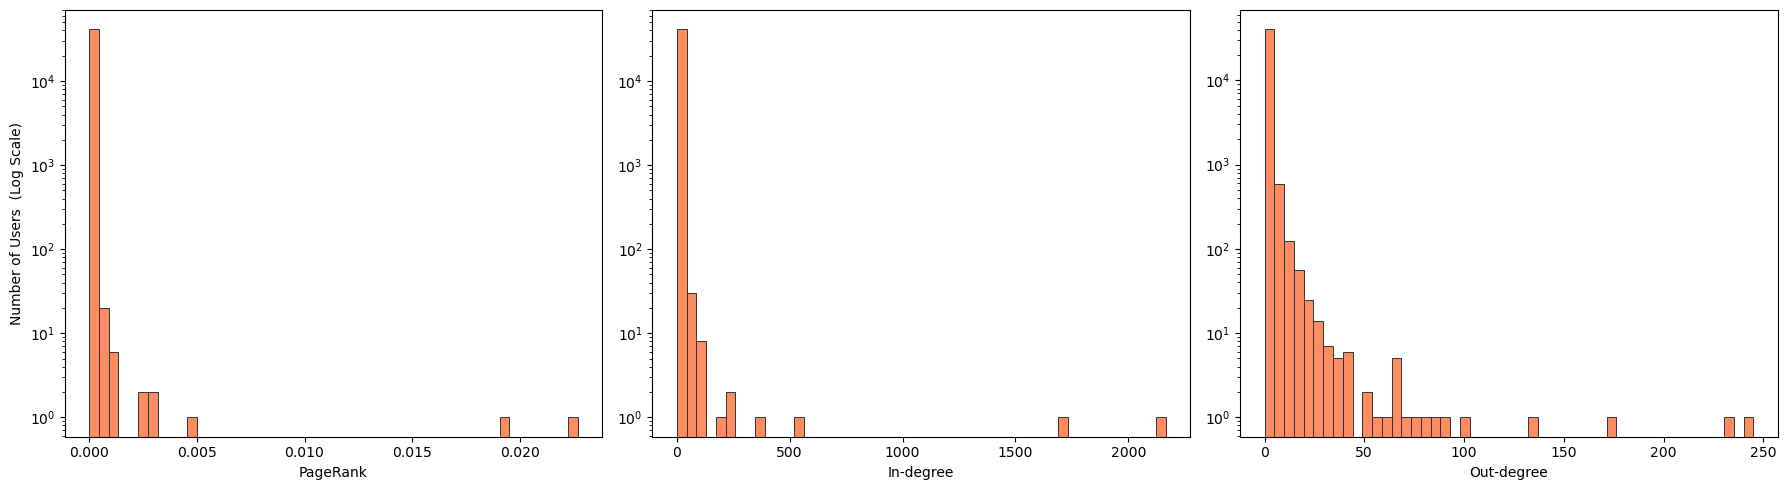

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)
first_color = sns.color_palette("Set2")[1]

# PageRank
axes[0].hist(stats_df['PageRank'], bins=50, color=first_color, log=True, edgecolor=".2", linewidth=0.7)
axes[0].set_xlabel('PageRank')
axes[0].set_ylabel('Number of Users  (Log Scale)')

# In-degree
axes[1].hist(stats_df['In-Degree'], bins=50, color=first_color, log=True, edgecolor=".2", linewidth=0.7)
axes[1].set_xlabel('In-degree')

# Out-degree
axes[2].hist(stats_df['Out-Degree'], bins=50, color=first_color, log=True, edgecolor=".2", linewidth=0.7)
axes[2].set_xlabel('Out-degree')

plt.tight_layout()
plt.savefig('reply_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

In [239]:
#FILTRO grafo reply - utenti attivi

# 1. Identifica i nodi che vuoi tenere (es. chi è stato risposto almeno 2 volte)
threshold = 2 
core_nodes = [n for n, deg in dict(G_rep.degree()).items() if deg >= threshold]
# 2. Crea il sottografo (questo "taglia" gli archi verso chi non è nei top)
G_temp = G_rep.subgraph(core_nodes).copy()

# 3. RIMUOVI I NODI ISOLATI (Quelli rimasti senza archi dopo il taglio)
nodes_with_edges = [n for n, deg in dict(G_temp.degree()).items() if deg > 0]
G_reply_filtered = G_temp.subgraph(nodes_with_edges).copy()

print(f"Nodi finali: {G_reply_filtered.number_of_nodes()}")
print(f"Archi finali: {G_reply_filtered.number_of_edges()}")

Nodi finali: 6309
Archi finali: 8791


In [240]:
nx.write_gexf(G_reply_filtered, "reply_network_filtered.gexf")

**COMMUNITY DETECTION - REPLY**

In [242]:
# Louvain richiede un grafo non orientato
G_rep_undirected = G_reply_filtered.to_undirected()

In [21]:
#LOUVAIN
resolutions = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0]
n_runs = 20  # Numero di tentativi per ogni risoluzione

print(f"Analisi Multi-run ({n_runs} iterazioni) con LOUVAIN:")

for res in resolutions:
    best_mod_for_res = -1
    best_n_comm_for_res = 0
    
    # Eseguiamo l'algoritmo n_runs volte per questa specifica risoluzione
    for i in range(n_runs):
        partition = community_louvain.best_partition(
            G_rep_undirected, 
            resolution=res, 
            weight='Weight'
        )
        
        # Calcolo modularità per questo tentativo
        current_mod = community_louvain.modularity(partition, G_rep_undirected, weight='Weight')
        
        # Se questo run è migliore dei precedenti, salviamo i dati
        if current_mod > best_mod_for_res:
            best_mod_for_res = current_mod
            best_n_comm_for_res = len(set(partition.values()))
    
    print(f"Risoluzione: {res:<4} | Community: {best_n_comm_for_res:<4} | Miglior Modularità: {best_mod_for_res:.4f}")

Analisi Multi-run (20 iterazioni) con LOUVAIN:
Risoluzione: 0.01 | Community: 2279 | Miglior Modularità: 0.5464
Risoluzione: 0.05 | Community: 1991 | Miglior Modularità: 0.5925


KeyboardInterrupt: 

Risultato -> $\gamma$ = 1.0 migliore (473 community, modularità $\approx$ 0.78)

In [243]:
# Recuperiamo gli archi dal grafo filtrato di NetworkX
edges = G_reply_filtered.edges(data=True)

# Creiamo la lista degli archi assicurandoci che 'Weight' sia float
edges_for_igraph = [(u, v, float(attr['Weight'])) for u, v, attr in edges]

# Inizializziamo igraph
g_ig_rep = ig.Graph.TupleList(edges_for_igraph, directed=True, edge_attrs=['weight'])

In [244]:
# METODO 1: LEIDEN CON OTTIMIZZAZIONE MODULARITÀ STANDARD 
# Questo metodo non accetta resolution_parameter, usa il default gamma=1.0
partition_rep = la.find_partition(
    g_ig_rep, 
    la.ModularityVertexPartition,
    weights='weight',
    seed=42
)

print("Risultati Modularità Standard Reply")
print(f"Number of communities: {len(partition_rep)}")
print(f"Modularity: {partition_rep.modularity:.4f}")

Risultati Modularità Standard Reply
Number of communities: 470
Modularity: 0.7626


In [ ]:
# LEIDEN RB
resolutions = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0]
n_runs = 20  # Numero di esecuzioni per ogni risoluzione 

print(f"Analisi Multi-run ({n_runs} iterazioni) con LEIDEN RB:")

for res in resolutions:
    best_mod_for_res = -1
    best_partition = None

    for i in range(n_runs):
        # Eseguiamo Leiden (senza seed fisso per permettere la variazione stocastica)
        # Usiamo n_iterations=-1 per far convergere l'algoritmo al meglio
        current_partition = la.find_partition(
            g_ig_rep, 
            la.RBConfigurationVertexPartition, 
            weights='weight', 
            resolution_parameter=res,
            n_iterations=-1,
            seed=123
        )
        
        # Valutiamo la modularità del run corrente
        current_mod = current_partition.modularity
        
        if current_mod > best_mod_for_res:
            best_mod_for_res = current_mod
            best_partition = current_partition
    
    print(f"Risolutore: {res:<5} | Community: {len(best_partition):<4} | Modularity: {best_mod_for_res:.4f}")

Risultato LB -> $\gamma$ = 1.0 migliore (472 community, modularità $\approx$ 0.77)

In [ ]:
# LEIDEN CPM
resolutions = [0.001, 0.005, 0.01, 0.05, 0.07, 0.1]
n_runs = 20  # Numero di esecuzioni per trovare l'ottimo locale (Practical Tip)

print(f"Analisi Multi-run ({n_runs} iterazioni) con LEIDEN CPM")

best_overall_partition = None
max_modularity_seen = -1

for res in resolutions:
    best_mod_for_res = -1
    best_part_for_res = None
    
    for i in range(n_runs):
        # Eseguiamo il run senza seed fisso per esplorare lo spazio delle soluzioni
        current_partition = la.find_partition(
            g_ig_rep,
            la.CPMVertexPartition,
            weights='weight',
            resolution_parameter=res,
            n_iterations=-1 # Assicura la massima ottimizzazione in ogni run
        )
        
        # Calcoliamo la modularità classica per validare la qualità della partizione
        current_mod = g_ig_rep.modularity(current_partition.membership, weights='weight')
        
        if current_mod > best_mod_for_res:
            best_mod_for_res = current_mod
            best_part_for_res = current_partition
            
    # Salviamo la partizione migliore in assoluto tra tutte le risoluzioni
    if best_mod_for_res > max_modularity_seen:
        max_modularity_seen = best_mod_for_res
        best_overall_partition = best_part_for_res
    
    print(f"Risolutore: {res:<6} | Community: {len(best_part_for_res):<4} | Modularity: {best_mod_for_res:.4f}")

*ANALISI GRAFICA - REPLY*

In [ ]:
data = []
resolutions = np.linspace(0, 2.0, 20+1)
n_runs = 10

for res in resolutions:
    for run in range(n_runs):

        # Louvain
        part_louvain = community_louvain.best_partition(
            G_rep_undirected,
            resolution=res,
            weight='Weight'
        )
        mod_louvain = community_louvain.modularity(
            part_louvain,
            G_rep_undirected,
            weight='Weight'
        )
        num_louvain = len(set(part_louvain.values()))

        # Leiden
        part_leiden = la.find_partition(
            g_ig_rep,
            la.RBConfigurationVertexPartition,
            weights='weight',
            resolution_parameter=res,
            n_iterations=-1
        )
        mod_leiden = part_leiden.modularity
        num_leiden = len(part_leiden)
        
        data.append({
            'Resolution': res,
            'Mod_Louvain': mod_louvain,
            'Num_Louvain': num_louvain,
            'Mod_Leiden': mod_leiden,
            'Num_Leiden': num_leiden
        })

In [ ]:
df = pd.DataFrame(data)
stats = df.groupby('Resolution').agg(['mean', 'std']).reset_index()

In [ ]:
stats.columns = [
    '_'.join(col).strip('_') if isinstance(col, tuple) else col
    for col in stats.columns
]


fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

# Modularità (mean ± std)
ax1.errorbar(stats['Resolution'], stats['Mod_Leiden_mean'], yerr=stats['Mod_Leiden_std'], 
             fmt='-o', capsize=3, label='Leiden Modularity', color='tab:blue')

ax1.errorbar(stats['Resolution'], stats['Mod_Louvain_mean'], yerr=stats['Mod_Louvain_std'], 
             fmt='--s', capsize=3, label='Louvain Modularity', color='tab:red')

# Numero community (mean ± std)
ax2.errorbar(stats['Resolution'], stats['Num_Leiden_mean'], yerr=stats['Num_Leiden_std'], fmt='x', color='tab:blue', alpha=0.6, label='Leiden Communities')

ax2.errorbar(stats['Resolution'], stats['Num_Louvain_mean'], yerr=stats['Num_Louvain_std'], fmt='+', color='tab:red', alpha=0.6, label='Louvain Communities')


# Formattazione
ax1.set_xlabel(r'Resolution parameter $\gamma$')
ax1.set_ylabel('Modularity (mean ± std)')
ax2.set_ylabel('Communities (mean ± std)')
ax1.set_title('Modularity & Communities vs Resolution (20 runs)')
ax1.grid(True, linestyle='--', alpha=0.7)
ax2.grid(False)
ax1.set_axisbelow(True)

# Legenda unica
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='center right',
          frameon=True, fancybox=True,framealpha=1)

plt.tight_layout()
plt.savefig('modularity_REPLY.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
print(stats)

**ANALISI COMMUNITY REPLY**

stessa funzione di prima ma prendo solo risolutore = 1.0

In [245]:
# Scegliamo la risoluzione che abbiamo stabilito essere la migliore
target_res = 1.0
n_runs = 20

best_mod = -1
final_partition_object = None

for i in range(n_runs):
    current_partition = la.find_partition(
        g_ig_rep, 
        la.RBConfigurationVertexPartition, 
        weights='weight', 
        resolution_parameter=target_res,
        n_iterations=-1,
        seed=123
    )
    
    if current_partition.modularity > best_mod:
        best_mod = current_partition.modularity
        final_partition_object = current_partition

In [246]:
communities = final_partition_object.membership
n_communities = len(set(communities))
print(f"Numero totale di retweet community: {n_communities}")

Numero totale di retweet community: 473


In [247]:
from collections import Counter

community_sizes = Counter(communities)
community_df = pd.DataFrame([
    {'community_id': comm_id, 'size': size}
    for comm_id, size in community_sizes.items()
]).sort_values('size', ascending=False)

print("\nTop 10 community per dimensione:")
print(community_df.head(10))


Top 10 community per dimensione:
    community_id  size
6              0   500
2              1   449
12             2   422
13             3   323
14             4   312
30             5   295
7              6   204
16             7   203
4              8   158
23             9   145


Non facciamo analisi su tutte 474 community, scegliamo un criterio per selezionarle: soglia 95° percentile

In [249]:
sizes = community_df['size'].values
# Definizione del 95° percentile
threshold = np.percentile(sizes, 95)
print(f"Soglia (95° percentile): {threshold:.2f} nodi")

# Identificazione delle community significative
# Creiamo una lista di tuple (id_community, dimensione)
significant_comms = []
for comm_id, size in community_sizes.items():
    if size > threshold:
        significant_comms.append((comm_id, size))

# Ordiniamo per dimensione decrescente
significant_comms.sort(key=lambda x: x[1], reverse=True)

print(f"Community totali: {len(sizes)}")
print(f"Community sopra la soglia: {len(significant_comms)}")
for cid, s in significant_comms:
    print(f"ID Community: {cid} | Dimensione: {s}")

significant_df = community_df[community_df['size'] > threshold].copy()

Soglia (95° percentile): 91.80 nodi
Community totali: 473
Community sopra la soglia: 24
ID Community: 0 | Dimensione: 500
ID Community: 1 | Dimensione: 449
ID Community: 2 | Dimensione: 422
ID Community: 3 | Dimensione: 323
ID Community: 4 | Dimensione: 312
ID Community: 5 | Dimensione: 295
ID Community: 6 | Dimensione: 204
ID Community: 7 | Dimensione: 203
ID Community: 8 | Dimensione: 158
ID Community: 9 | Dimensione: 145
ID Community: 10 | Dimensione: 143
ID Community: 11 | Dimensione: 141
ID Community: 12 | Dimensione: 134
ID Community: 13 | Dimensione: 127
ID Community: 14 | Dimensione: 126
ID Community: 15 | Dimensione: 124
ID Community: 16 | Dimensione: 123
ID Community: 18 | Dimensione: 108
ID Community: 17 | Dimensione: 108
ID Community: 19 | Dimensione: 107
ID Community: 20 | Dimensione: 104
ID Community: 21 | Dimensione: 103
ID Community: 22 | Dimensione: 99
ID Community: 23 | Dimensione: 96


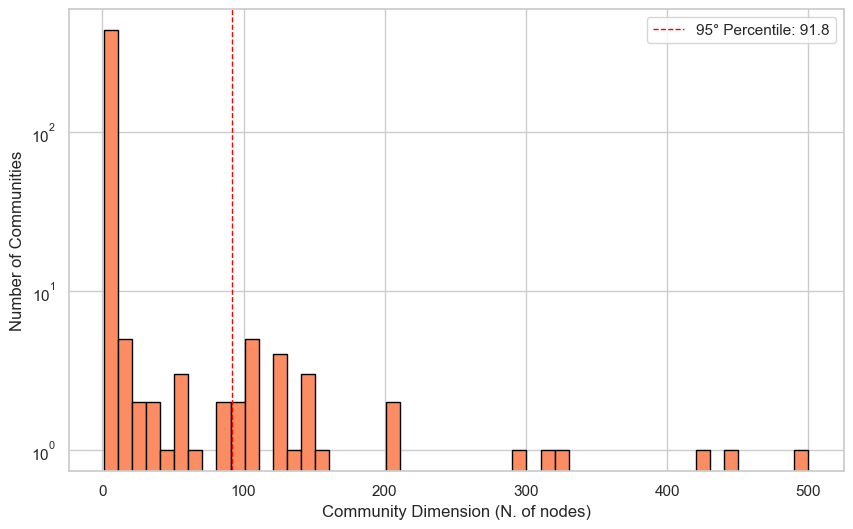

In [250]:
# 1. Grafico a barre di tutte le 182 community
p95_value = community_df['size'].quantile(0.95)
first_color = sns.color_palette("Set2")[1]
plt.figure(figsize=(10, 6))
plt.hist(community_df['size'], bins=50, color=first_color, log=True,edgecolor='black')
plt.axvline(p95_value, color='red', linestyle='--', linewidth=1, 
            label=f'95° Percentile: {p95_value:.1f}')
plt.xlabel('Community Dimension (N. of nodes)')
plt.ylabel('Number of Communities')
plt.legend()
plt.savefig('comm_rep.png', dpi=300, bbox_inches='tight')
plt.show()

community tenute -> 24

**E-INDEX -> OMOFILIA**

L'omofilia è la tendenza degli individui a stringere legami o interagire con persone simili a loro

In [251]:
# Creiamo un dizionario Nodo -> Community per velocizzare i calcoli
node_to_comm = {i: comm for i, comm in enumerate(communities)}
analysis_results = []

print(f"\n{'ID':>3} | {'Size':>4} | {'EI Index':>8} | {'Insular':>7} | {'Top 3 Influencers (Interni)':<40}")
print("-" * 90)

for cid in significant_df['community_id']:
    # Estraiamo i nodi appartenenti a questa specifica community
    nodes_in_comm = [i for i, comm in enumerate(communities) if comm == cid]
    
    # CALCOLO E-I INDEX PESATO 
    """
    Formula:
    --------
    E-I Index = (External_Weight - Internal_Weight) / (External_Weight + Internal_Weight)
    
    Range: [-1, +1]
    -1 = massima omofilia (solo link interni) → ECHO CHAMBER
    +1 = massima eterofilia (solo link esterni) → BRIDGE COMMUNITY
     0 = bilanciato (50% interni, 50% esterni)
    
    IMPORTANTE: mode='out' per evitare di contare gli archi due volte
    """
    
    internal_weight = 0
    external_weight = 0
    
    for node in nodes_in_comm:
        # MODE='OUT' per evitare duplicati
        out_edges = g_ig_rep.es.select(_source=node)
        
        for edge in out_edges:
            target = edge.target
            weight = edge['weight']  # Usa il peso dei retweet
            
            if node_to_comm[target] == cid:
                internal_weight += weight
            else:
                external_weight += weight
    
    # Formula E-I Index: (E - I) / (E + I)
    denom = (external_weight + internal_weight)
    ei_index = (external_weight - internal_weight) / denom if denom > 0 else 0
    
    # Calcola anche l'Insularity -> formation of homogeneous, and isolated groups or "bubbles," characterized by high homophily
    # Insularity = percentuale di interazioni interne
    # 0% = completamente aperta, 100% = completamente chiusa
    insularity = (internal_weight / denom) if denom > 0 else 0
    
    # IDENTIFICAZIONE LEADER (In-Degree nel sottografo)
    subgraph = g_ig_rep.subgraph(nodes_in_comm)
    # Calcoliamo la forza (strength) basata sui pesi dei retweet ricevuti
    in_strengths = subgraph.strength(mode='in', weights='weight')
    
    # Accoppiamo nomi e punteggi, poi ordiniamo
    leader_list = sorted(zip(subgraph.vs['name'], in_strengths), key=lambda x: x[1], reverse=True)
    top_3_names = [name for name, score in leader_list[:3]]
    leaders_str = ", ".join(top_3_names)
    
    # RISULTATI
    analysis_results.append({
        'ID': cid,
        'Size': len(nodes_in_comm),
        'EI_Index': ei_index,
        'Insularity': insularity,
        'Internal_Weight': internal_weight,
        'External_Weight': external_weight,
        'Leaders': leaders_str
    })
    
    print(f"{int(cid):>3} | {len(nodes_in_comm):>4} | {ei_index:>8.3f} | {insularity:>6.1%} | {leaders_str:<40}")


 ID | Size | EI Index | Insular | Top 3 Influencers (Interni)             
------------------------------------------------------------------------------------------
  0 |  500 |   -0.704 |  85.2% | User_24425, User_24938, User_24381      
  1 |  449 |   -0.723 |  86.1% | User_24408, User_24460, User_24521      
  2 |  422 |   -0.663 |  83.2% | User_3106, User_24582, User_24803       
  3 |  323 |   -0.772 |  88.6% | User_25410, User_24960, User_25923      
  4 |  312 |   -0.498 |  74.9% | User_24398, User_26181, User_24397      
  5 |  295 |   -0.783 |  89.2% | User_13734, User_27808, User_27732      
  6 |  204 |   -0.591 |  79.6% | User_20338, User_28391, User_25239      
  7 |  203 |   -0.582 |  79.1% | User_20958, User_25621, User_29812      
  8 |  158 |   -0.540 |  77.0% | User_25039, User_24533, User_24567      
  9 |  145 |   -0.529 |  76.4% | User_24906, User_27619, User_25028      
 10 |  143 |   -0.641 |  82.0% | User_50, User_6204, User_92             
 11 |  141 |   -0.5

*Di cosa parlano le community? Analisi hashtag*

In [80]:
nome_utente = reverse_mapping.get('User_25410', "ID non trovato")
print(f"L'utente con ID 26397 è: {nome_utente}")

L'utente con ID 26397 è: cryptojack


In [253]:
reverse_mapping = {v: k for k, v in mapping.items()}

In [254]:
# DataFrame che mappa ogni utente alla sua community
df_communities = pd.DataFrame({
    'user_id': g_ig_rep.vs['name'],
    'community_id': final_partition_object.membership
})

In [255]:
df_communities['real_name'] = df_communities['user_id'].map(reverse_mapping)

In [256]:
# 1. Filtriamo solo i retweet dalla colonna 'edge_info'
df_reply_raw = df_edges_raw[df_edges_raw['edge_info'].apply(lambda x: x[2] == 'reply')]

# 2. Creiamo il DataFrame finale espandendo la tupla e aggiungendo il testo
df_reply = pd.DataFrame(
    df_reply_raw['edge_info'].tolist(), 
    columns=['Source', 'Target', 'Type'], 
    index=df_reply_raw.index
)

# 3. Aggiungiamo la colonna del testo originale dal DataFrame pulito
df_reply['Tweet'] = df_reply_raw['Tweet']
df_reply['Date'] = df_clean.loc[df_reply_raw.index, 'Date']  # Usa gli indici originali

In [257]:
df_reply['Source_ID'] = df_reply['Source'].map(mapping)
df_reply['Target_ID'] = df_reply['Target'].map(mapping)

# 3. Ora facciamo il merge con df_communities usando gli ID
df_merged = df_reply.merge(
    df_communities, 
    left_on='Source_ID', 
    right_on='user_id', 
    how='inner'
)

In [258]:
# Uniamo i due DataFrame basandoci sul nome utente
df_merged = df_merged.drop(columns=['user_id'])
print(f"Tweet totali mappati: {len(df_merged)}")

Tweet totali mappati: 16597


In [259]:
from collections import Counter

def get_top_hashtags(text_series, top_n=10):
    # Funzione veloce per estrarre hashtag dal testo
    hashtags = text_series.str.findall(r'#(\w+)').explode().str.lower()
    return hashtags.value_counts().head(top_n)

# Analizziamo le community del significant_df (community sopra al 90° percentile)
significant_df_clean = significant_df.reset_index()
for cid in significant_df['community_id']:
    # Filtriamo i tweet della community specifica
    comm_tweets = df_merged[df_merged['community_id'] == cid]['Tweet']
    
    top_tags = get_top_hashtags(comm_tweets)
    
    print(f"\n Hashtag Dominanti Community {cid}")
    if not top_tags.empty:
        print(top_tags)
    else:
        print("Nessun hashtag trovato in questa community.")


 Hashtag Dominanti Community 0
Tweet
chatgpt                   1357
ai                         232
artificialintelligence      64
openai                      39
leadership                  22
designthinking              18
entrepreneur                18
twitter                     14
elonmusk                    14
web3                        13
Name: count, dtype: int64

 Hashtag Dominanti Community 1
Tweet
chatgpt                   1062
ai                         177
openai                      61
artificialintelligence      27
microsoft                   22
chatbot                     20
tech                        19
gpt4                        18
generativeai                18
google                      18
Name: count, dtype: int64

 Hashtag Dominanti Community 2
Tweet
chatgpt        1357
ai              151
thread          125
openai           21
prompt           16
usecase          15
tools            14
google           14
bing             13
semanticweb      12
Name: count, d

In [ ]:
# Lista di hashtag da ignorare
removed_hashtag = {'chatgpt', 'ai', 'openai', 'artificialintelligence'}

def get_top_hashtags_filtered(text_series, top_n=10):
    # 1. Estrazione e normalizzazione (minuscolo)
    hashtags = text_series.str.findall(r'#(\w+)').explode().str.lower()
    
    # 2. Filtriamo i termini nella blacklist
    # Usiamo .dropna() per sicurezza e ~ .isin() per escludere la blacklist
    filtered_hashtags = hashtags[~hashtags.isin(removed_hashtag)].dropna()
    
    # 3. Conteggio e formattazione
    return filtered_hashtags.value_counts().head(top_n)

for cid in significant_df['community_id']:
    # Filtriamo i tweet della community specifica
    comm_tweets = df_merged[df_merged['community_id'] == cid]['Tweet']
    
    top_tags = get_top_hashtags_filtered(comm_tweets)
    
    print(f"\n Hashtag Dominanti Community {cid}")
    if not top_tags.empty:
        print(top_tags)
    else:
        print("Nessun hashtag trovato in questa community.")

In [ ]:
top_comms = significant_df['community_id'].tolist()

# Configuriamo la griglia (3 righe x 3 colonne)
fig, axes = plt.subplots(8, 3, figsize=(15, 30))
axes = axes.flatten()

for i, cid in enumerate(top_comms):
    # Filtriamo e normalizziamo gli hashtag (come abbiamo fatto prima)
    comm_tweets = df_merged[df_merged['community_id'] == cid]['Tweet']
    hashtags = comm_tweets.str.findall(r'#(\w+)').explode().str.lower()
    
    # Rimuoviamo hashtag comuni
    removed_hashtag = {'chatgpt', 'ai', 'openai', 'artificialintelligence'}
    filtered_tags = hashtags[~hashtags.isin(removed_hashtag)].dropna()
    
    # Prendiamo i top 10
    top_10 = filtered_tags.value_counts().head(10)
    
    # Creazione del grafico a barre
    sns.barplot(x=top_10.values, y=top_10.index,hue=top_10.index, ax=axes[i], palette="crest_r")
    
    axes[i].set_title(f"Community {cid}: Top 10 Hashtag", fontsize=10, fontweight='bold')
    axes[i].set_xlabel("Frequenza")
    axes[i].set_ylabel("")

# Pulizia del layout
plt.tight_layout()
plt.savefig('hashtag_communities_reply.png', dpi=300)

plt.show()

*Applichiamo TF-IDF*

In [260]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Raggruppiamo tutti gli hashtag di ogni community in una "frase" unica
comm_docs = []
ids = significant_df['community_id'].tolist()

for cid in ids:
    # Estraiamo tutti gli hashtag della community e li uniamo in una stringa
    tweets = df_merged[df_merged['community_id'] == cid]['Tweet']
    tags = tweets.str.findall(r'#(\w+)').explode().str.lower().dropna()
    comm_docs.append(" ".join(tags))

# 2. Applichiamo TF-IDF
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(comm_docs)
feature_names = vectorizer.get_feature_names_out()

print(f"\n{'ID':>3} | {'Hashtag (Top 10 per TF-IDF Score)':<80}")
print("-" * 120)

for i, cid in enumerate(ids):
    # Otteniamo i punteggi della riga i (community i)
    scores = tfidf_matrix.getrow(i).toarray()[0]
    
    # Troviamo i 5 indici con il valore TF-IDF più alto
    top_indices = scores.argsort()[-10:][::-1]
    
    # Creiamo la lista di hashtag con il relativo punteggio (arrotondato)
    top_terms = [f"{feature_names[idx]} ({scores[idx]:.3f})" for idx in top_indices if scores[idx] > 0]
    
    terms_str = ", ".join(top_terms)
    print(f"{int(cid):>3} | {terms_str}")

print("-" * 120)


 ID | Hashtag (Top 10 per TF-IDF Score)                                               
------------------------------------------------------------------------------------------------------------------------
  0 | chatgpt (0.977), ai (0.167), artificialintelligence (0.052), entrepreneur (0.046), leadership (0.045), designthinking (0.040), openai (0.028), elonmusk (0.020), twitter (0.018), web3 (0.014)
  1 | chatgpt (0.975), ai (0.163), openai (0.056), autopraise (0.039), chatbot (0.029), artificialintelligence (0.028), microsoft (0.027), tech (0.026), generativeai (0.026), roleplayinggame (0.026)
  2 | chatgpt (0.970), thread (0.191), ai (0.108), usecase (0.038), tools (0.031), semanticweb (0.030), prompt (0.026), freeprompt (0.023), promptengineering (0.017), githubcopilot (0.017)
  3 | chatgpt (0.774), ai (0.344), crypto (0.234), nowai (0.214), aibot (0.171), defi (0.164), eth (0.124), openai (0.107), btc (0.086), data (0.078)
  4 | chatgpt (0.988), ai (0.117), openai (0.037), peter

In [261]:
removed_hashtag = {'chatgpt', 'ai', 'openai', 'artificialintelligence'}

# 2. Raggruppamento hashtag filtrati per community
comm_docs = []
ids = significant_df['community_id'].tolist()

for cid in ids:
    tweets = df_merged[df_merged['community_id'] == cid]['Tweet']
    # Estraiamo gli hashtag
    tags = tweets.str.findall(r'#(\w+)').explode().str.lower().dropna()
    # Applichiamo il filtro 
    filtered_tags = tags[~tags.isin(removed_hashtag)]
    comm_docs.append(" ".join(filtered_tags))

# 3. Calcolo TF-IDF
# Usiamo stop_words='english' come ulteriore sicurezza se ci fossero termini comuni residui
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(comm_docs)
feature_names = vectorizer.get_feature_names_out()

# 4. Output testuale formattato
print(f"\n{'ID':>3} | {'Hashtag (TF-IDF Score - Filtered)':<80}")
print("-" * 110)

for i, cid in enumerate(ids):
    scores = tfidf_matrix.getrow(i).toarray()[0]
    top_indices = scores.argsort()[-10:][::-1]
    
    # Filtriamo per assicurarci di non stampare termini con score zero
    top_terms = [f"{feature_names[idx]} ({scores[idx]:.3f})" for idx in top_indices if scores[idx] > 0]
    
    terms_str = ", ".join(top_terms)
    print(f"{int(cid):>3} | {terms_str}")

print("-" * 110)


 ID | Hashtag (TF-IDF Score - Filtered)                                               
--------------------------------------------------------------------------------------------------------------
  0 | entrepreneur (0.387), leadership (0.380), designthinking (0.343), elonmusk (0.173), twitter (0.156), web3 (0.120), charactergpt (0.114), hamilton68 (0.114), entrepreneurship (0.114), woke (0.104)
  1 | autopraise (0.286), chatbot (0.214), microsoft (0.198), tech (0.194), generativeai (0.192), roleplayinggame (0.191), technology (0.182), martech (0.169), dungeonanddragons (0.167), cloud (0.153)
  2 | thread (0.877), usecase (0.173), tools (0.143), semanticweb (0.139), prompt (0.119), freeprompt (0.104), promptengineering (0.077), githubcopilot (0.077), prompts (0.074), tutorial (0.072)
  3 | crypto (0.451), nowai (0.413), aibot (0.330), defi (0.316), eth (0.240), btc (0.166), data (0.151), meme (0.144), midjourney (0.139), neuroscience (0.136)
  4 | petertodd (0.334), leilan (0.334), g

Salvato: reply_tfidf_communities_part1.png


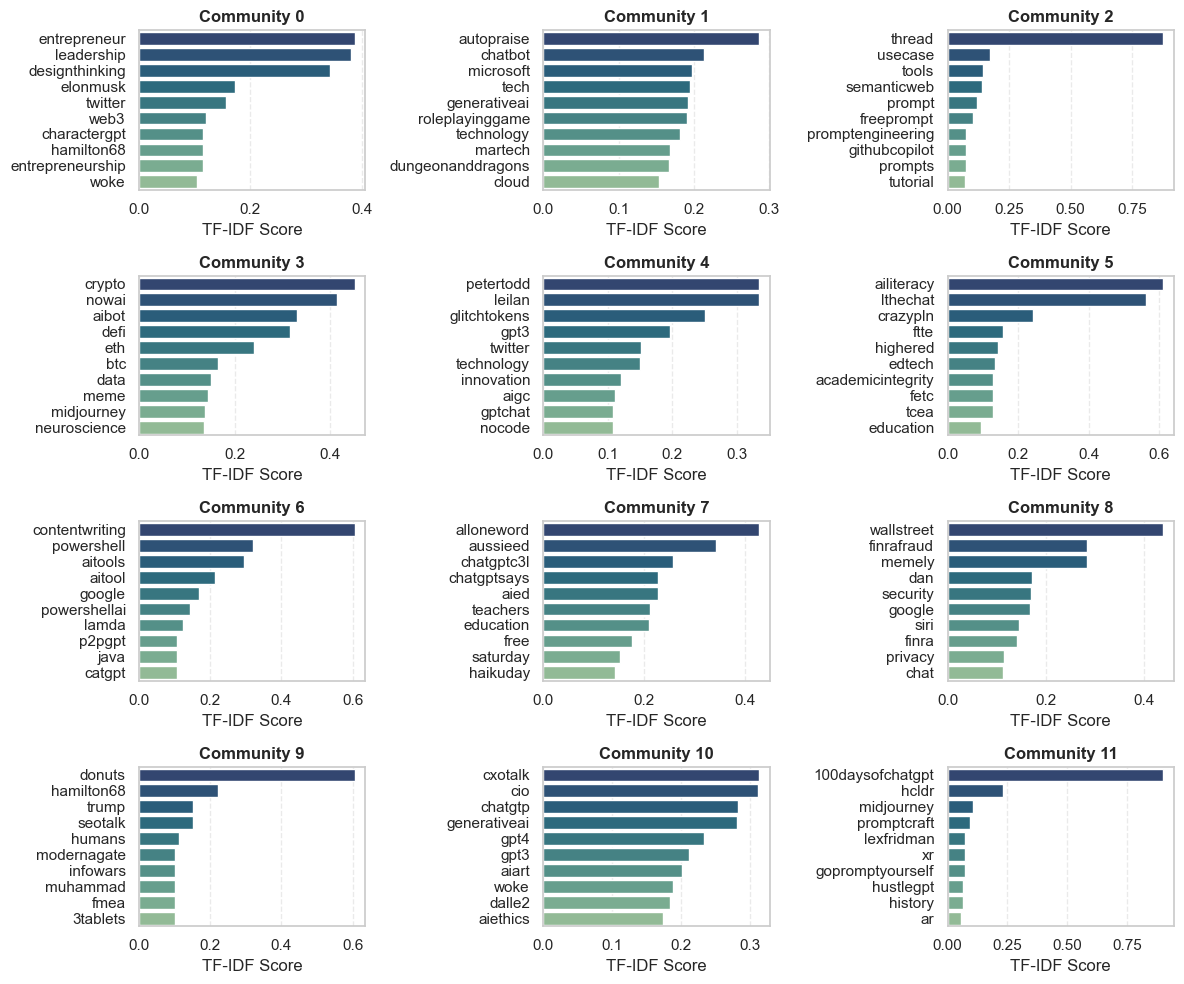

C:\Users\marti\AppData\Local\Temp\ipykernel_16920\1522582248.py:57: UserWarning: Glyph 24590 (\N{CJK UNIFIED IDEOGRAPH-600E}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\marti\AppData\Local\Temp\ipykernel_16920\1522582248.py:57: UserWarning: Glyph 20040 (\N{CJK UNIFIED IDEOGRAPH-4E48}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\marti\AppData\Local\Temp\ipykernel_16920\1522582248.py:57: UserWarning: Glyph 29992 (\N{CJK UNIFIED IDEOGRAPH-7528}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\marti\AppData\Local\Temp\ipykernel_16920\1522582248.py:60: UserWarning: Glyph 24590 (\N{CJK UNIFIED IDEOGRAPH-600E}) missing from font(s) Arial.
  plt.savefig(filename, dpi=300)
C:\Users\marti\AppData\Local\Temp\ipykernel_16920\1522582248.py:60: UserWarning: Glyph 20040 (\N{CJK UNIFIED IDEOGRAPH-4E48}) missing from font(s) Arial.
  plt.savefig(filename, dpi=300)
C:\Users\marti\AppData\Local\Temp\ipykernel_16920\1522582248.py:60: UserWarning: Glyph 29992 (\N{CJK 

Salvato: reply_tfidf_communities_part2.png


C:\Users\marti\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24590 (\N{CJK UNIFIED IDEOGRAPH-600E}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\marti\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20040 (\N{CJK UNIFIED IDEOGRAPH-4E48}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\marti\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29992 (\N{CJK UNIFIED IDEOGRAPH-7528}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


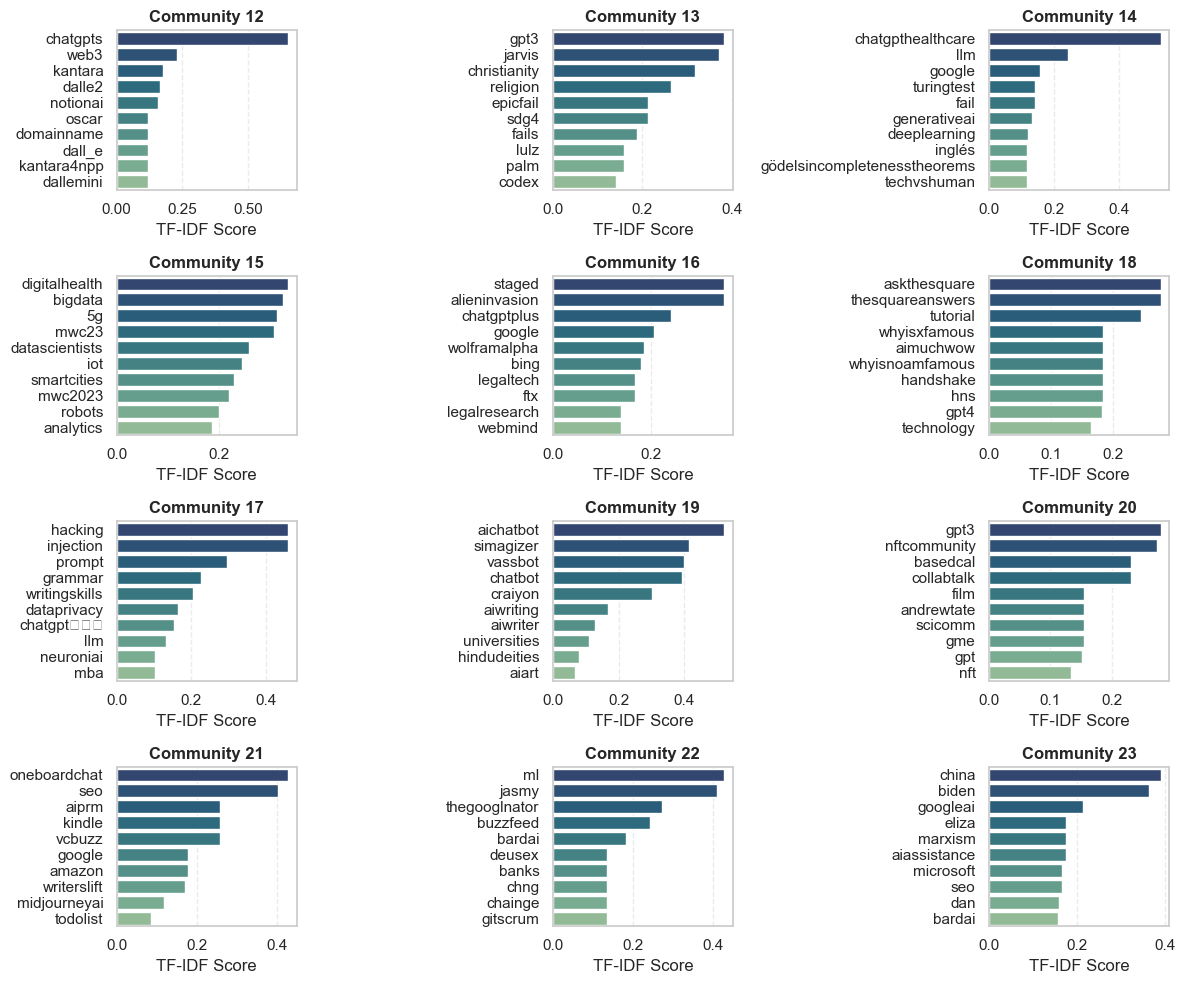

In [263]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Parametri di divisione
n_communities = len(ids)
communities_per_page = 12
rows, cols = 4, 3

# Ciclo per generare le due immagini
for page in range(2):
    # Inizializza la figura per la pagina corrente
    fig, axes = plt.subplots(rows, cols, figsize=(12, 10))
    axes = axes.flatten()
    
    # Determina quali ID processare in questa pagina
    start_idx = page * communities_per_page
    end_idx = start_idx + communities_per_page
    
    for i, idx_in_page in enumerate(range(start_idx, end_idx)):
        # Evitiamo errori se gli ID totali non sono multipli esatti di 12
        if idx_in_page >= n_communities:
            axes[i].axis('off')
            continue
            
        cid = ids[idx_in_page]
        
        # Estrazione dati TF-IDF
        scores = tfidf_matrix.getrow(idx_in_page).toarray()[0]
        top_indices = scores.argsort()[-10:][::-1]
        
        df_tfidf = pd.DataFrame({
            'hashtag': [feature_names[idx] for idx in top_indices],
            'score': [scores[idx] for idx in top_indices]
        })
        
        # Plotting
        if not df_tfidf.empty and df_tfidf['score'].sum() > 0:
            sns.barplot(
                data=df_tfidf, 
                x='score', 
                y='hashtag', 
                ax=axes[i], 
                hue='hashtag', 
                palette='crest_r',
                legend=False
            )
            axes[i].set_title(f"Community {cid}", fontsize=12, fontweight='bold')
        else:
            axes[i].text(0.5, 0.5, "Dati insufficienti", ha='center')
            axes[i].set_title(f"Community {cid}: No Data")

        axes[i].set_xlabel("TF-IDF Score")
        axes[i].set_ylabel("")
        axes[i].grid(axis='x', linestyle='--', alpha=0.4)

    plt.tight_layout()
    # Salva con nomi diversi: parte1.png e parte2.png
    filename = f'reply_tfidf_communities_part{page+1}.png'
    plt.savefig(filename, dpi=300)
    print(f"Salvato: {filename}")
    plt.show()

**SENTIMENT**

In [264]:
def clean_tweet(text):
    if pd.isna(text) or text == "":
        return ""
    
    # 1. Rimuovi URL (http, https, www)
    text = re.sub(r'http\S+', 'http', text)
    
    # 2. Rimuovi Menzioni (@user)
    text = re.sub(r'@\w+', '', text)
    
    # 3. Rimuovi il prefisso "RT " tipico dei retweet
    text = re.sub(r'^RT[:\s]+', '', text)
    
    # 4. Rimuovi caratteri speciali inutili (ma tieni punteggiatura ed emoji)
    # Rimuoviamo solo i simboli che possono sporcare (es. &amp; > &)
    #text = text.replace("&amp;", "&")
    #text = text.replace("#", "")
    
    # 5. Rimuovi spazi extra e a capo
    #text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Applichiamo la pulizia prima dell'analisi
df_merged['tweet_clean'] = df_merged['Tweet'].apply(clean_tweet)

In [265]:
# Salva in CSV
df_merged.to_csv('sentiment_data_rep.csv', 
                 index=False, 
                 sep=',', 
                 encoding='utf-8-sig') # 'utf-8-sig' serve per far leggere bene gli accenti a Excel

In [266]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# 1. Inizializzazione VADER
analyzer = SentimentIntensityAnalyzer()

def get_vader_score(text):
    if pd.isna(text) or text == "":
        return 0
    # Restituiamo solo il 'compound' score (bilanciato tra -1 e 1)
    return analyzer.polarity_scores(str(text))['compound']

# 2. Calcolo del sentiment sul DataFrame dei retweet mappati
df_merged['sentiment_score'] = df_merged['Tweet'].apply(get_vader_score)

# 3. Aggregazione dei risultati per community
# Calcoliamo media, deviazione standard e numero di tweet per community
community_sentiment_stats = df_merged.groupby('community_id')['sentiment_score'].agg([
    'mean', 
    'std', 
    'count'
]).reset_index()

# Rinominiamo le colonne per chiarezza
community_sentiment_stats.columns = ['community_id', 'sentiment_mean', 'sentiment_std', 'tweet_count']

# 4. Filtriamo solo per le community significative (utilizzando il tuo threshold del 95° percentile)
# Assumiamo che 'significant_df' contenga gli ID delle community sopra la soglia
significant_ids = significant_df['community_id'].unique()
final_analysis = community_sentiment_stats[community_sentiment_stats['community_id'].isin(significant_ids)].copy()

# 5. Classificazione qualitativa del sentiment medio
def label_sentiment(score):
    if score >= 0.05: return 'Positivo'
    elif score <= -0.05: return 'Negativo'
    else: return 'Neutro'

final_analysis['sentiment_label'] = final_analysis['sentiment_mean'].apply(label_sentiment)

# Ordiniamo per sentiment più positivo
final_analysis = final_analysis.sort_values(by='sentiment_mean', ascending=False)

print("\n Analisi Sentiment Community Significative")
print(final_analysis)


 Analisi Sentiment Community Significative
    community_id  sentiment_mean  sentiment_std  tweet_count sentiment_label
15            15        0.584519       0.437925          760        Positivo
5              5        0.355645       0.455105          991        Positivo
20            20        0.321215       0.460269          327        Positivo
11            11        0.316623       0.422169          441        Positivo
21            21        0.307571       0.459082          238        Positivo
7              7        0.294108       0.436103          570        Positivo
17            17        0.291662       0.423638          274        Positivo
18            18        0.287328       0.425988          278        Positivo
19            19        0.284618       0.433218          467        Positivo
4              4        0.283022       0.450032          837        Positivo
10            10        0.281029       0.436864          383        Positivo
2              2        0.273190

In [267]:
#entropia shannon
from scipy.stats import entropy

def calculate_community_entropy(series):
    n_bins = 20
    # Arrotondiamo i valori per creare delle "bin" (es. intervalli di 0.1)
    # Altrimenti ogni punteggio unico verrebbe considerato una categoria a sé
    bins = np.histogram(series, bins=np.linspace(-1, 1, n_bins+1))[0]
    # Normalizziamo per ottenere una distribuzione di probabilità
    probs = bins / bins.sum()
    return entropy(probs)/ np.log(n_bins) if entropy(probs) > 0 else 0

# Calcoliamo l'entropia per ogni community significativa
entropy_df = df_merged.groupby('community_id')['sentiment_score'].apply(calculate_community_entropy).reset_index()
entropy_df.columns = ['community_id', 'sentiment_entropy']

# Uniamola ai tuoi risultati precedenti
final_analysis = final_analysis.merge(entropy_df, on='community_id')
print(final_analysis[['community_id', 'sentiment_mean', 'sentiment_entropy']].sort_values(by='sentiment_entropy'))

    community_id  sentiment_mean  sentiment_entropy
11             2        0.273190           0.744538
0             15        0.584519           0.763999
12             3        0.268054           0.815385
7             18        0.287328           0.816370
6             17        0.291662           0.816494
20            22        0.154539           0.818793
8             19        0.284618           0.826329
2             20        0.321215           0.834339
3             11        0.316623           0.836771
14             8        0.246808           0.845571
5              7        0.294108           0.850670
21            23        0.147946           0.852654
17             1        0.202549           0.855097
13             6        0.255246           0.858917
15            12        0.240506           0.861101
18            16        0.197339           0.863251
9              4        0.283022           0.870619
1              5        0.355645           0.872312
16          

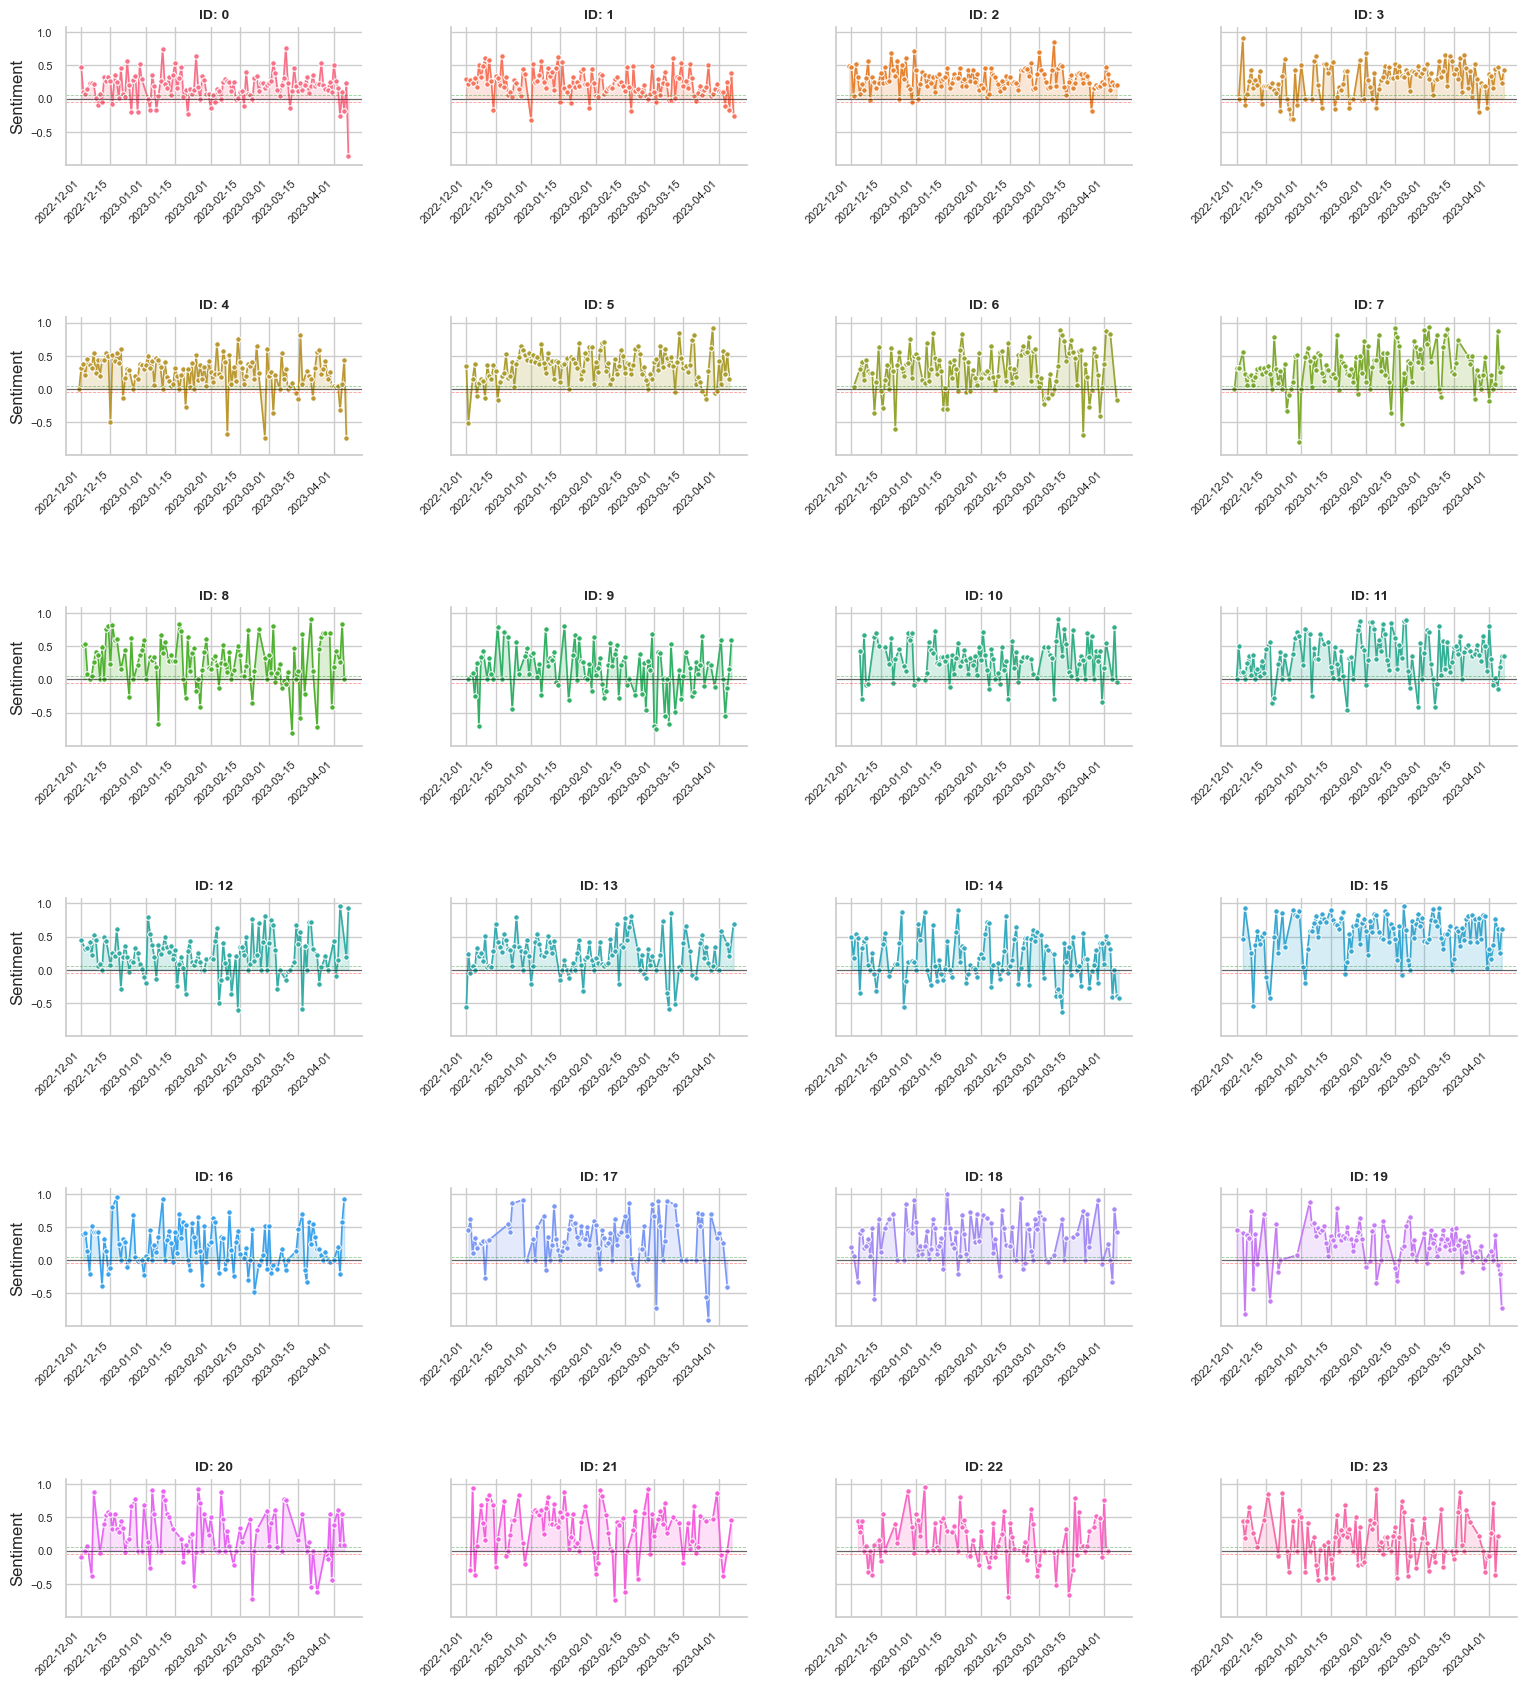

In [268]:
# 1. Preparazione dei dati e filtro community significative
df_plot = df_merged.reset_index()
df_plot['Day'] = pd.to_datetime(df_plot['Date']).dt.date 

significant_ids = significant_df['community_id'].unique()
grid_data = df_plot.groupby(['Day', 'community_id'])['sentiment_score'].mean().reset_index()
grid_data_filtered = grid_data[grid_data['community_id'].isin(significant_ids)].copy()

# 2. Creazione della FacetGrid con col_wrap=4
# Avendo 4 colonne, riduciamo height e aspect per non far uscire il grafico dallo schermo
g = sns.FacetGrid(grid_data_filtered, col="community_id", col_wrap=4, 
                  hue="community_id", palette="husl", 
                  height=3, aspect=1.3) 

# 3. Mappatura dei grafici
g.map(plt.fill_between, "Day", "sentiment_score", alpha=0.2)
g.map(sns.lineplot, "Day", "sentiment_score", marker="o", linewidth=1.2, markersize=4)

# 4. Raffinatezze estetiche
g.set_axis_labels("", "Sentiment")
g.set_titles("ID: {col_name}", fontweight='bold', size=10)

for ax in g.axes.flat:
    ax.tick_params(labelbottom=True, labelsize=8) 
    
    # Linee di riferimento (Neutral, Positive threshold, Negative threshold)
    ax.axhline(0, color='black', linewidth=0.8, alpha=.5)
    ax.axhline(0.05, color='green', linestyle='--', linewidth=0.6, alpha=.4)
    ax.axhline(-0.05, color='red', linestyle='--', linewidth=0.6, alpha=.4)
    
    # Ruotiamo le date
    plt.setp(ax.get_xticklabels(), rotation=45, horizontalalignment='right')

# Aumentiamo lo spazio per far leggere bene le date tra le righe
plt.subplots_adjust(hspace=1.1, wspace=0.3, top=0.92)
plt.savefig('vader_reply.png', dpi=300, bbox_inches='tight')
plt.show()

**roBERTa**

In [270]:
bert_df=pd.read_csv('BERT_sent_rep.csv')

In [271]:
merged_df = pd.merge(bert_df, significant_df[['community_id']], on='community_id', how='inner')

# 6. Aggregazione: calcolo media e conteggio
community_sentiment = merged_df.groupby('community_id')['sentiment_numeric'].agg([
    ('sentiment_medio', 'mean'),
    ('sentiment_std', 'std'),
    ('sentiment_entropy', calculate_community_entropy),
    ('n_tweet', 'count')
]).reset_index()
community_sentiment.columns = ['community_id', 'sentiment_medio','sentiment_std', 'sentiment_entropy', 'n_tweet']

# 7. AGGIUNTA COLONNA COMPLESSIVA (con soglia per il Neutro)
# Un valore tra -0.1 e 0.1 può essere considerato Neutro
def definisci_sentiment_finale(media):
    if media > 0.05:
        return 'Positivo'
    elif media < -0.05:
        return 'Negativo'
    else:
        return 'Neutro'

community_sentiment['sentiment_complessivo'] = community_sentiment['sentiment_medio'].apply(definisci_sentiment_finale)

# 8. Unione con i dati originali (significant_df)
final_results = (pd.merge(community_sentiment, significant_df, on='community_id')).round(4)

# Ordiniamo per vedere le più polarizzate
final_results = final_results.sort_values(by='community_id', ascending=False)

print(final_results[['community_id', 'sentiment_medio', 'sentiment_std', 'sentiment_entropy', 'sentiment_complessivo', 'n_tweet']])

    community_id  sentiment_medio  sentiment_std  sentiment_entropy  \
23            23          -0.0214         0.5113             0.6392   
22            22           0.0340         0.5240             0.6676   
21            21           0.0881         0.5133             0.6679   
20            20          -0.0768         0.5215             0.6524   
19            19           0.1783         0.5770             0.7471   
18            18          -0.0280         0.5133             0.6673   
17            17           0.4373         0.5190             0.6856   
16            16           0.1689         0.5540             0.7295   
15            15           0.0390         0.4906             0.6378   
14            14           0.1802         0.5231             0.6597   
13            13           0.0446         0.5752             0.7478   
12            12          -0.0670         0.5137             0.6448   
11            11           0.0236         0.5339             0.7014   
10    

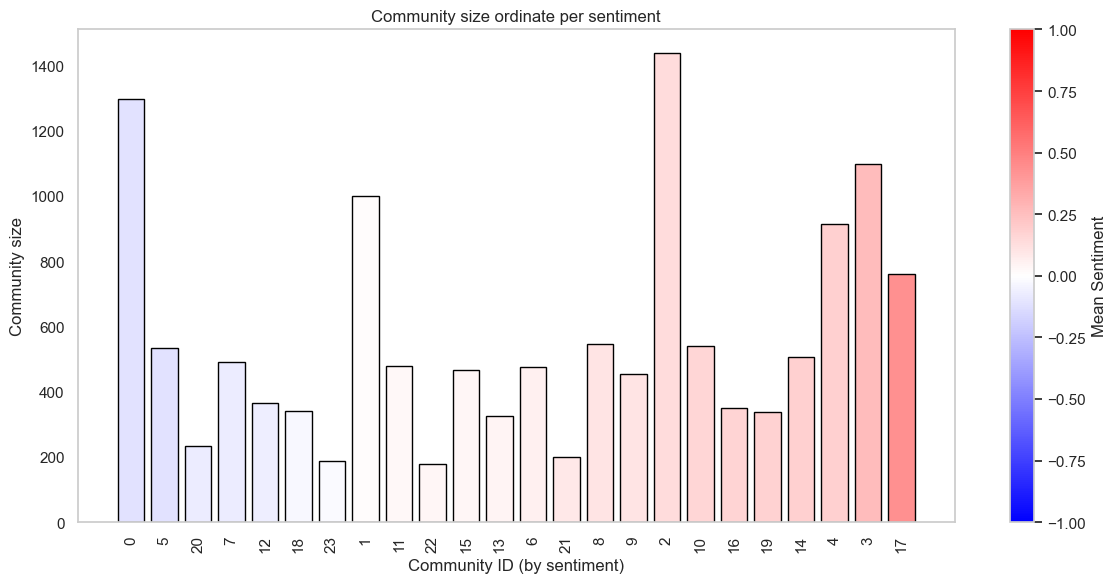

In [327]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Ordina per sentiment
plot_df = final_results.sort_values("sentiment_medio")

x = plot_df["community_id"]
y = plot_df["n_tweet"]
sentiment = plot_df["sentiment_medio"]

cmap = plt.cm.bwr
norm = mcolors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)

colors = cmap(norm(sentiment))

fig, ax = plt.subplots(figsize=(12,6))

bars = ax.bar(
    range(len(x)),
    y,
    color=colors,
    edgecolor="black"
)

ax.set_xticks(range(len(x)))
ax.set_xticklabels(x, rotation=90)

ax.set_xlabel("Community ID (by sentiment)")
ax.set_ylabel("Community size")
ax.set_title("Community size ordinate per sentiment")
ax.grid(False)

# colorbar corretta
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

fig.colorbar(sm, ax=ax, label="Mean Sentiment")

plt.tight_layout()
plt.savefig('sent_compl_rep.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# 1. Preparazione dei dati e filtro community significative
df_plot = merged_df.reset_index()
df_plot['Day'] = pd.to_datetime(df_plot['Date']).dt.date 

significant_ids = significant_df['community_id'].unique()
grid_data = df_plot.groupby(['Day', 'community_id'])['sentiment_numeric'].mean().reset_index()
grid_data_filtered = grid_data[grid_data['community_id'].isin(significant_ids)].copy()

# 2. Creazione della FacetGrid con col_wrap=4
# Avendo 4 colonne, riduciamo height e aspect per non far uscire il grafico dallo schermo
g = sns.FacetGrid(grid_data_filtered, col="community_id", col_wrap=4, 
                  hue="community_id", palette="husl", 
                  height=3, aspect=1.3) 

# 3. Mappatura dei grafici
g.map(plt.fill_between, "Day", "sentiment_numeric", alpha=0.2)
g.map(sns.lineplot, "Day", "sentiment_numeric", marker="o", linewidth=1.2, markersize=4)

# 4. Raffinatezze estetiche
g.set_axis_labels("", "Sentiment")
g.set_titles("ID: {col_name}", fontweight='bold', size=10)

for ax in g.axes.flat:
    ax.tick_params(labelbottom=True, labelsize=8) 
    
    # Linee di riferimento (Neutral, Positive threshold, Negative threshold)
    ax.axhline(0, color='black', linewidth=0.8, alpha=.5)
    ax.axhline(0.05, color='green', linestyle='--', linewidth=0.6, alpha=.4)
    ax.axhline(-0.05, color='red', linestyle='--', linewidth=0.6, alpha=.4)
    
    # Ruotiamo le date
    plt.setp(ax.get_xticklabels(), rotation=45, horizontalalignment='right')

# Aumentiamo lo spazio per far leggere bene le date tra le righe
plt.subplots_adjust(hspace=1.1, wspace=0.3, top=0.92)
plt.savefig('BERT_reply.png', dpi=300, bbox_inches='tight')
plt.show()

**Gruppo controllo random**

In [87]:
from tqdm import tqdm

# parametri rete reply
N = g_ig_rep.vcount()
M = g_ig_rep.ecount()

# SIMULAZIONE RANDOM
iterazioni = 100
random_modularity_leiden = []

for i in tqdm(range(iterazioni)):
    # Genera grafo random con stessi nodi e stessi archi del grafo reply
    G_rand = ig.Graph.Erdos_Renyi(n=N, m=M, directed=True)
    
    # Converti a non diretto per Leiden
    G_rand_undir = G_rand.as_undirected(mode="collapse")
    
    try:
        if G_rand_undir.ecount() > 0:
            # Applica Leiden
            partition = la.find_partition(
                G_rand_undir, 
                la.ModularityVertexPartition,
                seed=42
            )
            mod = partition.modularity
        else:
            mod = 0
    except:
        mod = 0
        
    random_modularity_leiden.append(mod)

# confronto e p-vlaue
def print_random_comparison(metric_name, original, rand_values):
    # Pulizia dai NaN
    vals = np.array([v for v in rand_values if not np.isnan(v)])
    n = len(vals)
    
    if n == 0:
        print(f"Dati insufficienti per {metric_name}")
        return
    
    mean_rnd = np.mean(vals)
    std_rnd = np.std(vals)
    
    # 1. Z-Score
    if std_rnd > 0:
        z_score = (original - mean_rnd) / std_rnd
    else:
        z_score = 0
        
    # 2. P-Value Empirico (Two-Tailed)
    diff_orig = abs(original - mean_rnd)
    diff_rnd = np.abs(vals - mean_rnd)
    
    r = np.sum(diff_rnd >= diff_orig)
    p_value = (r + 1) / (n + 1)
        
    print(f"\n {metric_name.upper()} ")
    print(f"   Reale:   {original:.5f}")
    print(f"   Random:  {mean_rnd:.5f} (± {std_rnd:.5f})")
    print(f"   Z-Score: {z_score:.2f}")
    print(f"   P-Value: {p_value:.4f}")
    
    if p_value < 0.05:
        print("   *** Differenza significativa (Non è casuale)")
    else:
        print("   Risultato compatibile col caso")

# --- 4. STAMPA RISULTATI ---
print("RISULTATI: MODULARITÀ LEIDEN - dataset reply vs generato")

# modularità Leiden originale 
orig_modularity_leiden = final_partition_object.modularity

print_random_comparison("Modularità (Leiden)", orig_modularity_leiden, random_modularity_leiden)

100%|██████████| 100/100 [00:23<00:00,  4.30it/s]

RISULTATI: MODULARITÀ LEIDEN - dataset reply vs generato

 MODULARITÀ (LEIDEN) 
   Reale:   0.76513
   Random:  0.69169 (± 0.00218)
   Z-Score: 33.70
   P-Value: 0.0099
   *** Differenza significativa (Non è casuale)


In [90]:
import numpy as np
import igraph as ig
import leidenalg as la
from tqdm import tqdm

# -----------------------------
# PARAMETRI RETE REALE
# -----------------------------
g = g_ig_rep  # usa qui il tuo grafo (retweet o reply)

N = g.vcount()
M = g.ecount()

iterazioni = 100

print(f"Simulazione su {iterazioni} grafi random (Erdos-Renyi G(n,m))")
print(f"Nodi: {N} | Archi: {M}")

# -----------------------------
# LISTE METRICHE RANDOM
# -----------------------------
random_modularity = []
random_clustering = []
random_betweenness = []

# -----------------------------
# SIMULAZIONE
# -----------------------------
for i in tqdm(range(iterazioni)):

    # 1. Generazione grafo random
    G_rand = ig.Graph.Erdos_Renyi(n=N, m=M, directed=True)

    # conversione per alcune metriche
    G_rand_undir = G_rand.as_undirected(mode="collapse")

    # -----------------
    # CLUSTERING
    # -----------------
    try:
        clust = G_rand_undir.transitivity_avglocal_undirected()
        random_clustering.append(clust)
    except:
        random_clustering.append(0)

    # -----------------
    # BETWEENNESS
    # -----------------
    try:
        if N < 5000:
            betw = np.mean(G_rand.betweenness())
        else:
            sample_nodes = np.random.choice(N, 500)
            betw = np.mean(G_rand.betweenness(vertices=sample_nodes))
        random_betweenness.append(betw)
    except:
        random_betweenness.append(0)

    # -----------------
    # MODULARITY
    # -----------------
    try:
        if G_rand_undir.ecount() > 0:
            partition = la.find_partition(
                G_rand_undir,
                la.ModularityVertexPartition,
                seed=42
            )
            random_modularity.append(partition.modularity)
        else:
            random_modularity.append(0)
    except:
        random_modularity.append(0)

# -----------------------------
# METRICHE GRAFO REALE
# -----------------------------

orig_modularity = final_partition_object.modularity
orig_clustering = g.as_undirected().transitivity_avglocal_undirected()
orig_betweenness = np.mean(g.betweenness())

# ==========================================
# 5. FUNZIONE DI CONFRONTO, Z-SCORE E P-VALUE
# ==========================================

def compare_metric(name, real_value, random_values):
    vals = np.array(random_values)
    mean_rand = np.mean(vals)
    std_rand = np.std(vals)
    n_sim = len(vals)

    # 1. Calcolo Z-score
    z_score = (real_value - mean_rand) / std_rand if std_rand > 0 else 0

    # 2. Calcolo P-value Empirico (Two-tailed)
    # Contiamo quante volte il valore random è più distante dalla media rispetto al valore reale
    # Usiamo la formula (count + 1) / (n + 1) per evitare p-value pari a 0.0
    distance_real = abs(real_value - mean_rand)
    outlier_count = np.sum(np.abs(vals - mean_rand) >= distance_real)
    p_value = (outlier_count + 1) / (n_sim + 1)

    print("\n" + "="*40)
    print(f"{name.upper()}")
    print("="*40)
    print(f"Valore Reale:    {real_value:.6f}")
    print(f"Media Random:    {mean_rand:.6f} ± {std_rand:.6f}")
    print(f"Z-score:         {z_score:.2f}")
    print(f"P-value:         {p_value:.4f}")

    # Interpretazione combinata
    if p_value <= 0.05:
        sig_status = "SIGNIFICATIVO"
        if z_score > 0:
            detail = "molto superiore al caso"
        else:
            detail = "molto inferiore al caso"
    else:
        sig_status = "NON SIGNIFICATIVO"
        detail = "compatibile con fluttuazioni casuali"

    print(f"Risultato:       {sig_status} ({detail})")

# -----------------------------
# STAMPA RISULTATI
# -----------------------------

compare_metric("Modularity", orig_modularity, random_modularity)
compare_metric("Clustering coefficient", orig_clustering, random_clustering)
compare_metric("Average betweenness", orig_betweenness, random_betweenness)

print("\nDensity reale:", g.density())
print("Average degree:", np.mean(g.degree()))

Simulazione su 100 grafi random (Erdos-Renyi G(n,m))
Nodi: 6309 | Archi: 8791


100%|██████████| 100/100 [02:45<00:00,  1.65s/it]


MODULARITY
Valore Reale:    0.765128
Media Random:    0.692131 ± 0.001969
Z-score:         37.08
P-value:         0.0099
Risultato:       SIGNIFICATIVO (molto superiore al caso)

CLUSTERING COEFFICIENT
Valore Reale:    0.031364
Media Random:    0.000464 ± 0.000270
Z-score:         114.45
P-value:         0.0099
Risultato:       SIGNIFICATIVO (molto superiore al caso)

AVERAGE BETWEENNESS
Valore Reale:    11.755270
Media Random:    30201.404581 ± 3470.068983
Z-score:         -8.70
P-value:         0.0099
Risultato:       SIGNIFICATIVO (molto inferiore al caso)

Density reale: 0.00022089509274679116
Average degree: 2.786812490093517


✅ Grafico con campana salvato: modularity_result_rep.png


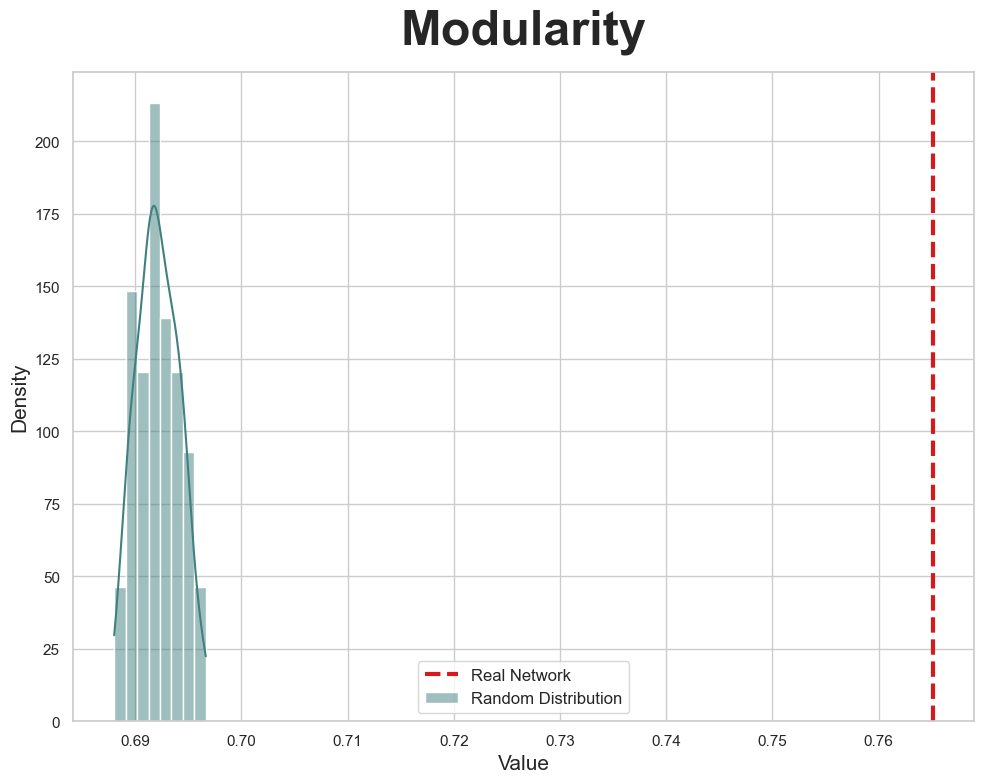

✅ Grafico con campana salvato: clustering_result_rep.png


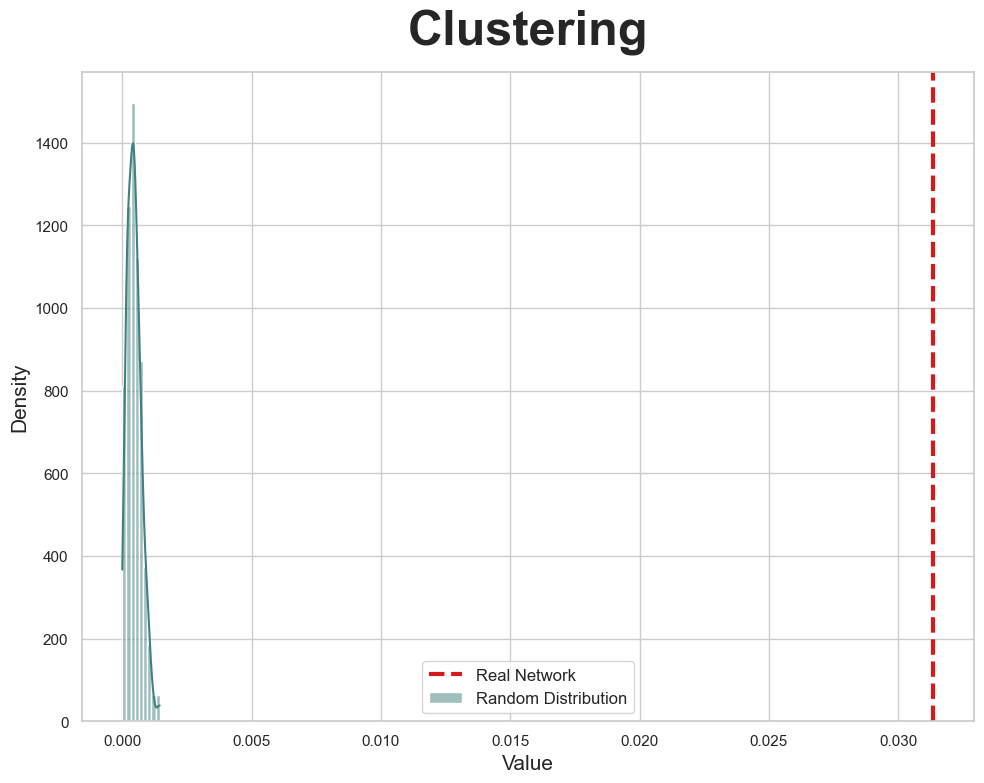

✅ Grafico con campana salvato: betweenness_result_rep.png


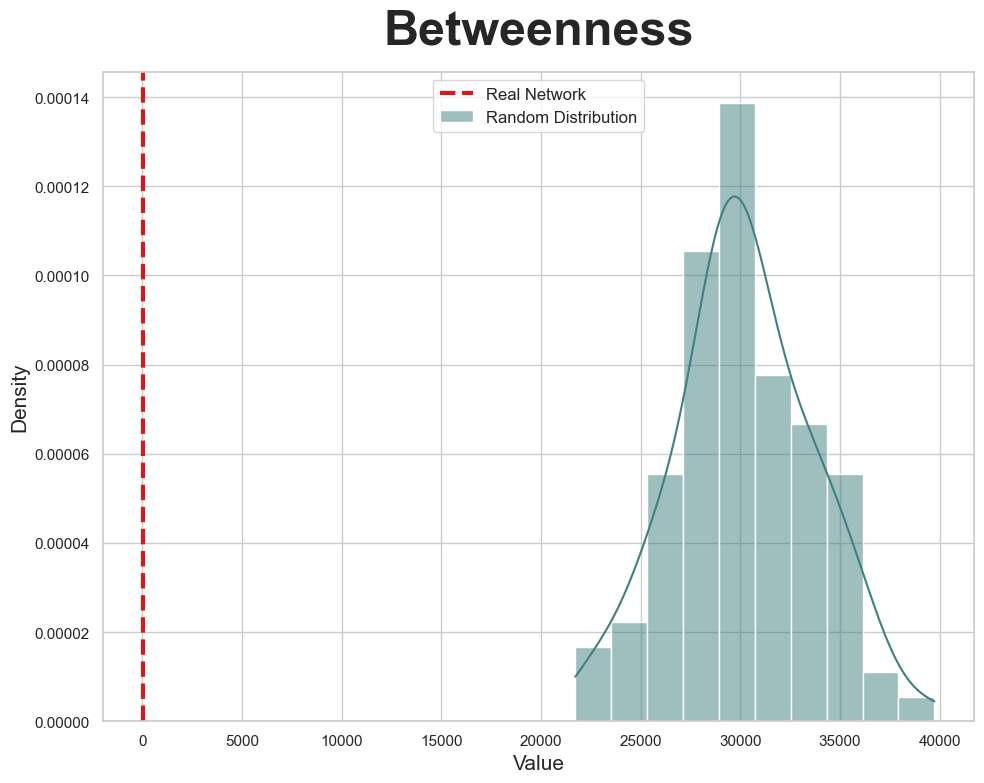

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np

def plot_distribution(random_values, real_value, title):
    # Setup estetico
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 8))
    
    # 1. DISEGNO ISTOGRAMMA + CAMPANA (KDE)
    # stat="density" serve per avere la curva sulla stessa scala dell'istogramma
    sns.histplot(random_values, kde=True, color="#408080", 
                 stat="density", label="Random Distribution", alpha=0.5)
    
    # 2. LINEA REALE
    plt.axvline(real_value, linestyle="--", linewidth=3, color="#D7191C",
                label=f"Real Network")
    
    # 3. TITOLO E ETICHETTE
    plt.title(title, fontsize=35, fontweight='bold', pad=20)
    plt.xlabel("Value", fontsize=15)
    plt.ylabel("Density", fontsize=15)
    plt.legend(fontsize=12)
    
    # 4. OTTIMIZZAZIONE SPAZI E SALVATAGGIO
    plt.tight_layout()
    clean_name = title.lower().replace(" ", "_")
    filename = f"{clean_name}_result_rep.png"
    plt.savefig(filename, dpi=300)
    
    print(f"✅ Grafico con campana salvato: {filename}")
    plt.show()

# Esempio di chiamata
plot_distribution(random_modularity, orig_modularity, "Modularity")
plot_distribution(random_clustering, orig_clustering, "Clustering")
plot_distribution(random_betweenness, orig_betweenness, "Betweenness")

**IRAN**

In [94]:
import kagglehub, glob, os
from kagglehub import KaggleDatasetAdapter
print("Scaricamento dataset Iran Protests (Konradb)...")
path = kagglehub.dataset_download("konradb/iran-protests-2022-tweets")

# Troviamo il file CSV (spesso sono divisi per mese, prendiamo il primo o uniamo)
csv_files = glob.glob(os.path.join(path, "*.csv"))
if not csv_files:
    raise ValueError("Nessun CSV trovato!")

# Per velocità prendiamo il file più grosso (spesso contiene il blocco principale)
file_path = max(csv_files, key=os.path.getsize)
print(f"Caricamento file: {os.path.basename(file_path)}")

# Leggiamo il dataset (limitiamo a 50k righe per velocità di test, rimuovi nrows per tutto)
df_iran = pd.read_csv(file_path) 
print(f"Righe caricate: {len(df_iran)}")

Scaricamento dataset Iran Protests (Konradb)...
Caricamento file: tweets.csv


C:\Users\marti\AppData\Local\Temp\ipykernel_16920\2149729698.py:16: DtypeWarning: Columns (5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df_iran = pd.read_csv(file_path)


Righe caricate: 589600


In [95]:
df_iran['date'] = pd.to_datetime(df_iran['date'], errors='coerce', utc=True)
df_iran = df_iran.dropna(subset=['date']) # Rimuoviamo date non valide

In [96]:
start_date = pd.Timestamp("2022-11-30", tz="UTC")
end_date = pd.Timestamp("2023-04-30", tz="UTC")

# Filtriamo
mask = (df_iran['date'] >= start_date) & (df_iran['date'] <= end_date)
df_iran = df_iran.loc[mask]

print(f"Tweet nel periodo selezionato ({start_date.date()} - {end_date.date()}): {len(df_iran)}")

Tweet nel periodo selezionato (2022-11-30 - 2023-04-30): 252319


In [97]:
# Conta quanti tweet ha scritto ogni utente
tweet_per_user = df_iran['user_name'].value_counts()

# Tengo solo utenti con almeno 3 tweet - evito bot
utenti_attivi = tweet_per_user[tweet_per_user >= 2].index
df_iran = df_iran[df_iran['user_name'].isin(utenti_attivi)].copy()

print("Tweet dopo filtro utenti attivi:", len(df_iran))
print("Utenti attivi:", df_iran['user_name'].nunique())

Tweet dopo filtro utenti attivi: 234845
Utenti attivi: 19061


In [98]:
def extract_edges_iran(row):
    tweet = str(row['text'])
    user = row['user_name']
    
    # Check for Retweet (starts with RT @user)
    if tweet.startswith('RT @'):
        mention = re.findall(r'^RT @(\w+)', tweet)
        if mention:
            return (user, mention[0], 'retweet')
            
    # Check for Reply (starts with @user)
    if tweet.startswith('@'):
        mention = re.findall(r'^@(\w+)', tweet)
        if mention:
            return (user, mention[0], 'reply')
            
    return None

In [99]:
# Applichiamo la funzione e creiamo una nuova colonna con la tupla (Source, Target, Type)
df_iran['edge_info'] = df_iran.apply(extract_edges_iran, axis=1)

# Rimuoviamo le righe dove la funzione ha restituito 'None' (i tweet normali)
df_edges_raw_ir = df_iran.dropna(subset=['edge_info'])

# Trasformiamo la colonna di tuple in tre colonne separate
df_edges_ir = pd.DataFrame(df_edges_raw_ir['edge_info'].tolist(), 
                        columns=['Source', 'Target', 'Type'], 
                        index=df_edges_raw_ir.index)

In [100]:
# RETWEET df
df_uk_ir = df_edges_ir[df_edges_ir['Type'] == 'retweet'].copy().groupby(['Source', 'Target']).size().reset_index(name='Weight')
df_uk_ir['Type'] = 'Directed'
#df_retweet.to_excel('retweet_data.xlsx', index=False)

# REPLY df
df_rep_ir = df_edges_ir[df_edges_ir['Type'] == 'reply'].copy().groupby(['Source', 'Target']).size().reset_index(name='Weight')
df_rep_ir['Type'] = 'Directed'

In [101]:
#GRAPGH RETWEET
G_rep_ir = nx.from_pandas_edgelist(df_rep_ir, 
                               source='Source', 
                               target='Target', 
                               edge_attr='Weight', 
                               create_using=nx.DiGraph())

print(f"Nodes (users): {G_rep_ir.number_of_nodes()}")
print(f"Labels (relations): {G_rep_ir.number_of_edges()}")
nx.write_gexf(G_rep_ir, "rep_network_uk.gexf")

Nodes (users): 26007
Labels (relations): 81829


In [155]:
## import numpy as np
import igraph as ig
import leidenalg as la
from tqdm import tqdm
import random

# ==========================================
# 1. SETUP PER RIPRODUCIBILITÀ
# ==========================================
SEED = 29
random.seed(SEED)
np.random.seed(SEED)
ig.set_random_number_generator(random.Random(SEED))

# ==========================================
# 2. PARAMETRI
# ==========================================
g_new = ig.Graph.from_networkx(G_rep_ir)
g_orig = g_ig_rep

N = g_orig.vcount()
M = g_orig.ecount()
iterazioni = 100

print(f"Simulazione su {iterazioni} sotto-grafi campionati")
print(f"Nodi target: {N}")
print(f"Archi target: {M}")

# -----------------------------
random_modularity = []
random_clustering = []
random_betweenness = []
# -----------------------------

# ==========================================
# 3. FUNZIONE DI CAMPIONAMENTO CON CONTROLLO ARCHI
# ==========================================
def sample_subgraph():

    max_attempts = 20

    for _ in range(max_attempts):

        sampled_nodes = random.sample(range(g_new.vcount()), N)
        G_sample = g_new.subgraph(sampled_nodes)

        m_sample = G_sample.ecount()

        # caso ideale
        if m_sample >= M:

            # taglia archi random fino a M
            edges_to_remove = random.sample(range(m_sample), m_sample - M)
            G_sample.delete_edges(edges_to_remove)

            return G_sample

    # fallback: se non troviamo abbastanza archi
    return G_sample


# ==========================================
# 4. SIMULAZIONE
# ==========================================
for i in tqdm(range(iterazioni)):

    G_sample = sample_subgraph()
    G_sample_undir = G_sample.as_undirected(mode="collapse")

    # --- CLUSTERING ---
    try:
        clust = G_sample_undir.transitivity_avglocal_undirected()
        random_clustering.append(clust)
    except:
        random_clustering.append(0)

    # --- BETWEENNESS ---
    try:
        if N > 5000:
            sample_nodes_betw = random.sample(range(G_sample.vcount()), 100)
            betw = np.mean(G_sample.betweenness(vertices=sample_nodes_betw))
        else:
            betw = np.mean(G_sample.betweenness())
        random_betweenness.append(betw)
    except:
        random_betweenness.append(0)

    # --- MODULARITY ---
    try:
        if G_sample_undir.ecount() > 0:
            partition = la.find_partition(
                G_sample_undir,
                la.ModularityVertexPartition,
                seed=SEED
            )
            random_modularity.append(partition.modularity)
        else:
            random_modularity.append(0)
    except:
        random_modularity.append(0)


# ==========================================
# 5. METRICHE GRAFO ORIGINALE
# ==========================================
orig_modularity = final_partition_object.modularity
orig_clustering = g_orig.as_undirected(mode="collapse").transitivity_avglocal_undirected()
orig_betweenness = np.mean(g_orig.betweenness())


# ==========================================
# 6. FUNZIONE CONFRONTO
# ==========================================
def compare_metric(name, real_value, random_values):

    vals = np.array(random_values)

    mean_rand = np.mean(vals)
    std_rand = np.std(vals)

    z_score = (real_value - mean_rand) / std_rand if std_rand > 0 else 0

    distance_real = abs(real_value - mean_rand)
    outlier_count = np.sum(np.abs(vals - mean_rand) >= distance_real)
    p_value = (outlier_count + 1) / (len(vals) + 1)

    print("\n" + "="*40)
    print(name.upper())
    print("="*40)
    print(f"Valore reale:  {real_value:.6f}")
    print(f"Random mean:   {mean_rand:.6f} ± {std_rand:.6f}")
    print(f"Z-score:       {z_score:.2f}")
    print(f"P-value:       {p_value:.4f}")

    if p_value <= 0.05:
        print("Risultato: SIGNIFICATIVO")
    else:
        print("Risultato: NON SIGNIFICATIVO")


# ==========================================
# 7. RISULTATI
# ==========================================
compare_metric("Modularity", orig_modularity, random_modularity)
compare_metric("Clustering", orig_clustering, random_clustering)
compare_metric("Betweenness", orig_betweenness, random_betweenness)

print("\n--------------------------------")
print(f"Density reale: {g_orig.density():.6f}")
print(f"Avg degree:    {np.mean(g_orig.degree()):.2f}")

Simulazione su 100 sotto-grafi campionati
Nodi target: 6309
Archi target: 8791


100%|██████████| 100/100 [00:33<00:00,  3.00it/s]


MODULARITY
Valore reale:  0.765128
Random mean:   0.640911 ± 0.030732
Z-score:       4.04
P-value:       0.0099
Risultato: SIGNIFICATIVO

CLUSTERING
Valore reale:  0.031364
Random mean:   0.000265 ± 0.000413
Z-score:       75.22
P-value:       0.0099
Risultato: SIGNIFICATIVO

BETWEENNESS
Valore reale:  11.755270
Random mean:   0.001400 ± 0.011047
Z-score:       1063.97
P-value:       0.0099
Risultato: SIGNIFICATIVO

--------------------------------
Density reale: 0.000221
Avg degree:    2.79


✅ Grafico con campana salvato: modularity_result_iran.png


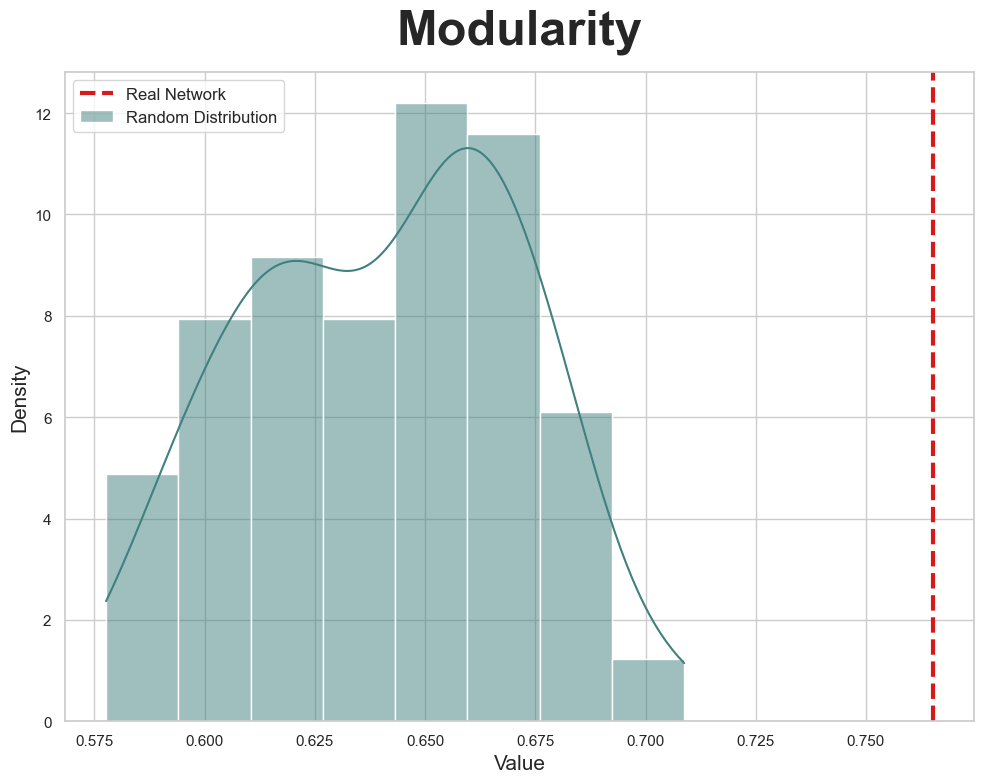

✅ Grafico con campana salvato: clustering_result_iran.png


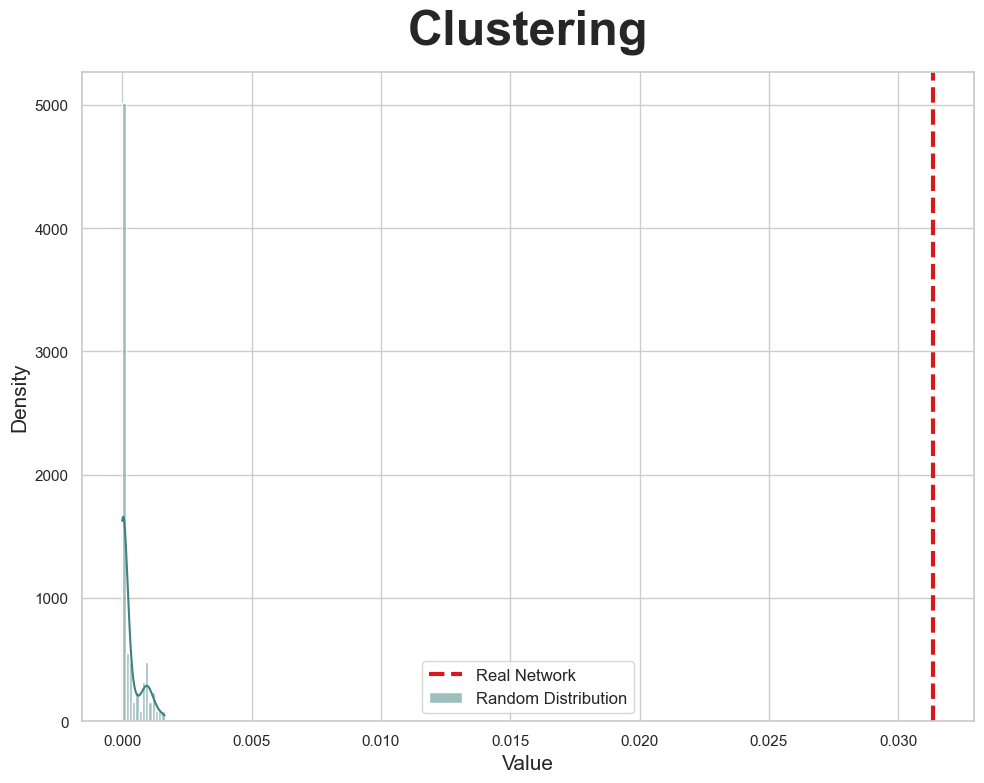

✅ Grafico con campana salvato: betweenness_result_iran.png


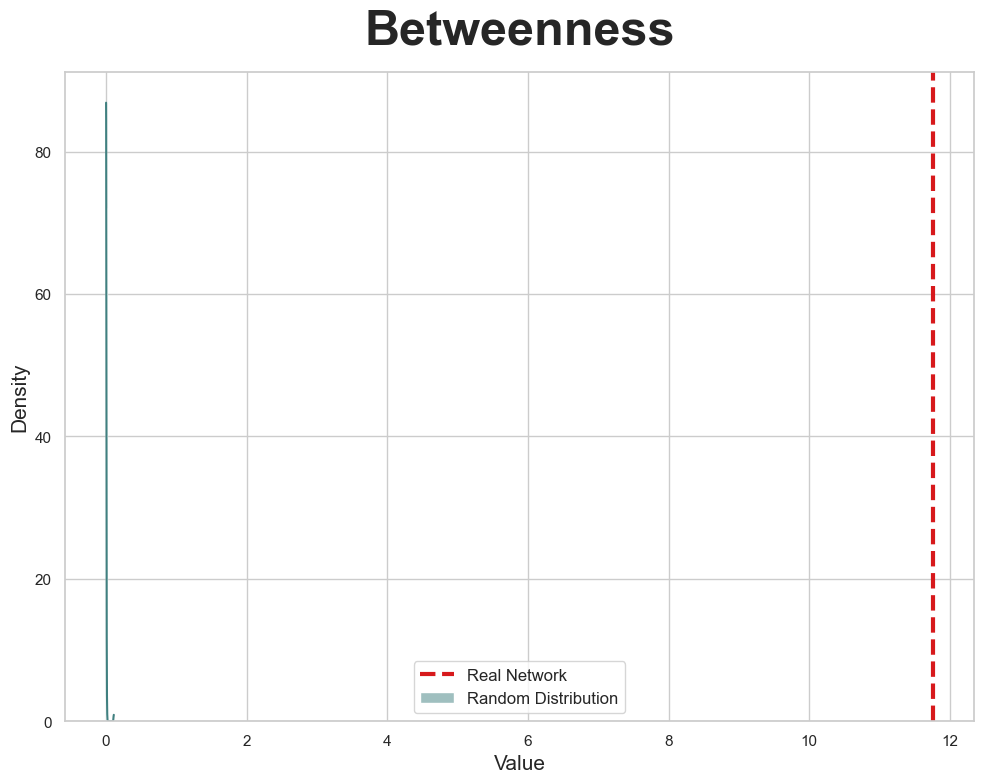

In [157]:
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np

def plot_distribution(random_values, real_value, title):
    # Setup estetico
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 8))
    
    # 1. DISEGNO ISTOGRAMMA + CAMPANA (KDE)
    # stat="density" serve per avere la curva sulla stessa scala dell'istogramma
    sns.histplot(random_values, kde=True, color="#408080", 
                 stat="density", label="Random Distribution", alpha=0.5)
    
    # 2. LINEA REALE
    plt.axvline(real_value, linestyle="--", linewidth=3, color="#D7191C",
                label=f"Real Network")
    
    # 3. TITOLO E ETICHETTE
    plt.title(title, fontsize=35, fontweight='bold', pad=20)
    plt.xlabel("Value", fontsize=15)
    plt.ylabel("Density", fontsize=15)
    plt.legend(fontsize=12)
    
    # 4. OTTIMIZZAZIONE SPAZI E SALVATAGGIO
    plt.tight_layout()
    clean_name = title.lower().replace(" ", "_")
    filename = f"{clean_name}_result_iran.png"
    plt.savefig(filename, dpi=300)
    
    print(f"✅ Grafico con campana salvato: {filename}")
    plt.show()

# Esempio di chiamata
plot_distribution(random_modularity, orig_modularity, "Modularity")
plot_distribution(random_clustering, orig_clustering, "Clustering")
plot_distribution(random_betweenness, orig_betweenness, "Betweenness")

**UK**

In [162]:
import zipfile
import pandas as pd
import os

# 1. IL TUO FILE ZIP
# La "r" davanti serve a far leggere bene i backslash di Windows
path_zip = r"C:\Users\marti\Downloads\archive (18).zip"

print(f"Apro l'archivio: {path_zip}...")

dataframes = []
files_trovati = 0

# Colonne da caricare (per risparmiare memoria RAM)
cols_to_keep = ['userid', 'tweetid', 'text', 'hashtags', 'language', 'in_reply_to_user_id', 'usercreatedts']

# 2. APRIAMO LO ZIP SENZA ESTRARLO
try:
    with zipfile.ZipFile(path_zip, 'r') as z:
        # Lista di tutti i file dentro l'archivio
        all_files = z.namelist()
        print(f"L'archivio contiene {len(all_files)} file totali.")
        print("Inizio la ricerca dei file per l'inverno 2022-2023...\n")

        for filename in all_files:
            # Prendiamo solo il nome del file pulito (senza cartelle)
            clean_name = os.path.basename(filename)
            
            # --- FILTRI PER DATA ---
            # Caso 1: Fine 2022 (Invariato)
            is_nov30 = clean_name.startswith("1130_")
            is_dec   = clean_name.startswith("12") and "_" in clean_name
            
            # Caso 2: Inizio 2023 (Mesi interi)
            is_jan   = "202301" in clean_name
            is_feb   = "202302" in clean_name
            is_mar   = "202303" in clean_name

            # Caso 3: Aprile 2023 (SOLO fino al giorno 08)
            is_apr = False
            if "202304" in clean_name:
                # Creiamo una lista di stringhe valide: da "20230401" a "20230408"
                giorni_validi = [f"202304{day:02d}" for day in range(1, 9)] 
                # Controlliamo se il nome del file contiene uno di questi giorni
                if any(giorno in clean_name for giorno in giorni_validi):
                    is_apr = True
            
            if is_nov30 or is_dec or is_jan or is_feb or is_mar or is_apr:
                try:
                    # Leggiamo il file CSV.GZIP direttamente da dentro lo ZIP principale
                    # Pandas è magico: legge lo stream decompresso al volo
                    with z.open(filename) as f:
                        df_temp = pd.read_csv(f, compression='gzip', usecols=cols_to_keep, 
                                            lineterminator='\n', on_bad_lines='skip')
                        dataframes.append(df_temp)
                        files_trovati += 1
                        print(f"Caricato: {clean_name}", end="\r")
                except Exception as e:
                    print(f"\nErrore su {clean_name}: {e}")

    # 3. UNIONE
    if dataframes:
        print(f"\n\nUnione di {files_trovati} file giornalieri...")
        df_uk = pd.concat(dataframes, ignore_index=True)
        
        # Sistemiamo le date
        df_uk['usercreatedts'] = pd.to_datetime(df_uk['usercreatedts'], errors='coerce')
        df_uk = df_uk.sort_values('usercreatedts')
        
        print("-" * 30)
        print("✅ DATASET COMPLETO PRONTO!")
        print(f"Totale Tweet: {len(df_uk)}")
        print(f"Periodo coperto: dal {df_uk['usercreatedts'].min()} al {df_uk['usercreatedts'].max()}")
        print(df_uk.head())
        
        # (Opzionale) Salva il risultato finale sul disco per non dover rifare tutto domani
        # full_df.to_csv("Dataset_Finale_Inverno.csv", index=False)
    else:
        print("❌ Nessun file trovato corrispondente alle date. Controlla che lo zip sia quello giusto.")

except FileNotFoundError:
    print(f"❌ Errore: Non trovo il file ZIP in: {path_zip}")
    print("Controlla di aver scritto giusto il percorso.")

Apro l'archivio: C:\Users\marti\Downloads\archive (18).zip...
L'archivio contiene 461 file totali.
Inizio la ricerca dei file per l'inverno 2022-2023...

Caricato: 20230408_UkraineCombinedTweetsDeduped.csv.gzip

Unione di 130 file giornalieri...
------------------------------
✅ DATASET COMPLETO PRONTO!
Totale Tweet: 11185048
Periodo coperto: dal 1970-01-01 00:00:00 al 2023-04-08 23:23:00
                      userid       usercreatedts              tweetid  \
374415   1282493780994560000 1970-01-01 00:00:00  1600525774913949696   
1277076  1365263329892179973 1970-01-01 00:00:00  1607064564205486080   
528738   1282493780994560000 1970-01-01 00:00:00  1601675035940622337   
6736004                  324 2006-06-06 15:04:24  1633830543413641221   
5423064                  509 2006-07-12 19:04:59  1630759450884849664   

                                                      text  \
374415   @cheddar @Plaid_Trudeau 🥊⛈️🍁\n#GunFreeze\n#Pou...   
1277076  Don’t ever wish a New Yorker #MerryCh

In [164]:
import pandas as pd

print(f"Prima della pulizia: {len(df_uk)} tweet")

# 1. Filtriamo tenendo solo le date successive al 1 Novembre 2022
# Questo elimina automaticamente il 1970 e qualsiasi altra data strana
df_uk = df_uk[df_uk['usercreatedts'] >= '2022-11-01']

print(f"Dopo la pulizia: {len(df_uk)} tweet")
print("-" * 30)
print(f"Nuovo periodo coperto: dal {df_uk['usercreatedts'].min()} al {df_uk['usercreatedts'].max()}")

Prima della pulizia: 11185048 tweet
Dopo la pulizia: 1001166 tweet
------------------------------
Nuovo periodo coperto: dal 2022-11-01 00:01:10 al 2023-04-08 23:23:00


In [166]:
# Conta quanti tweet ha scritto ogni utente
tweet_per_user = df_uk['userid'].value_counts()

# Tengo solo utenti con almeno 3 tweet - evito bot
utenti_attivi = tweet_per_user[tweet_per_user >= 2].index
df_uk_f = df_uk[df_uk['userid'].isin(utenti_attivi)].copy()

print("Tweet dopo filtro utenti attivi:", len(df_uk_f))
print("Utenti attivi:", df_uk_f['userid'].nunique())

Tweet dopo filtro utenti attivi: 917769
Utenti attivi: 55172


In [168]:
def extract_edges_uk(row):
    tweet = str(row['text'])
    user = row['userid']
    
    # Check for Retweet (starts with RT @user)
    if tweet.startswith('RT @'):
        mention = re.findall(r'^RT @(\w+)', tweet)
        if mention:
            return (user, mention[0], 'retweet')
            
    # Check for Reply (starts with @user)
    if tweet.startswith('@'):
        mention = re.findall(r'^@(\w+)', tweet)
        if mention:
            return (user, mention[0], 'reply')
            
    return None

In [170]:
# Applichiamo la funzione e creiamo una nuova colonna con la tupla (Source, Target, Type)
df_uk['edge_info'] = df_uk_f.apply(extract_edges_uk, axis=1)

# Rimuoviamo le righe dove la funzione ha restituito 'None' (i tweet normali)
df_edges_raw_uk = df_uk.dropna(subset=['edge_info'])

# Trasformiamo la colonna di tuple in tre colonne separate
df_edges_ik = pd.DataFrame(df_edges_raw_uk['edge_info'].tolist(), 
                        columns=['Source', 'Target', 'Type'], 
                        index=df_edges_raw_uk.index)

In [172]:
# RETWEET df
df_uk_rt = df_edges_ik[df_edges_ik['Type'] == 'retweet'].copy().groupby(['Source', 'Target']).size().reset_index(name='Weight')
df_uk_rt['Type'] = 'Directed'
#df_retweet.to_excel('retweet_data.xlsx', index=False)

# REPLY df
df_rep_uk = df_edges_ik[df_edges_ik['Type'] == 'reply'].copy().groupby(['Source', 'Target']).size().reset_index(name='Weight')
df_rep_uk['Type'] = 'Directed'

In [174]:
#GRAPGH RETWEET
G_rep_uk = nx.from_pandas_edgelist(df_rep_uk, 
                               source='Source', 
                               target='Target', 
                               edge_attr='Weight', 
                               create_using=nx.DiGraph())

print(f"Nodes (users): {G_rep_uk.number_of_nodes()}")
print(f"Labels (relations): {G_rep_uk.number_of_edges()}")
nx.write_gexf(G_rep_uk, "rep_network_uk.gexf")

Nodes (users): 40543
Labels (relations): 62054


In [176]:
## import numpy as np
import igraph as ig
import leidenalg as la
from tqdm import tqdm
import random

# ==========================================
# 1. SETUP PER RIPRODUCIBILITÀ
# ==========================================
SEED = 29
random.seed(SEED)
np.random.seed(SEED)
ig.set_random_number_generator(random.Random(SEED))

# ==========================================
# 2. PARAMETRI
# ==========================================
g_new = ig.Graph.from_networkx(G_rep_uk)
g_orig = g_ig_rep

N = g_orig.vcount()
M = g_orig.ecount()
iterazioni = 100

print(f"Simulazione su {iterazioni} sotto-grafi campionati")
print(f"Nodi target: {N}")
print(f"Archi target: {M}")

# -----------------------------
random_modularity = []
random_clustering = []
random_betweenness = []
# -----------------------------

# ==========================================
# 3. FUNZIONE DI CAMPIONAMENTO CON CONTROLLO ARCHI
# ==========================================
def sample_subgraph():

    max_attempts = 20

    for _ in range(max_attempts):

        sampled_nodes = random.sample(range(g_new.vcount()), N)
        G_sample = g_new.subgraph(sampled_nodes)

        m_sample = G_sample.ecount()

        # caso ideale
        if m_sample >= M:

            # taglia archi random fino a M
            edges_to_remove = random.sample(range(m_sample), m_sample - M)
            G_sample.delete_edges(edges_to_remove)

            return G_sample

    # fallback: se non troviamo abbastanza archi
    return G_sample


# ==========================================
# 4. SIMULAZIONE
# ==========================================
for i in tqdm(range(iterazioni)):

    G_sample = sample_subgraph()
    G_sample_undir = G_sample.as_undirected(mode="collapse")

    # --- CLUSTERING ---
    try:
        clust = G_sample_undir.transitivity_avglocal_undirected()
        random_clustering.append(clust)
    except:
        random_clustering.append(0)

    # --- BETWEENNESS ---
    try:
        if N > 5000:
            sample_nodes_betw = random.sample(range(G_sample.vcount()), 100)
            betw = np.mean(G_sample.betweenness(vertices=sample_nodes_betw))
        else:
            betw = np.mean(G_sample.betweenness())
        random_betweenness.append(betw)
    except:
        random_betweenness.append(0)

    # --- MODULARITY ---
    try:
        if G_sample_undir.ecount() > 0:
            partition = la.find_partition(
                G_sample_undir,
                la.ModularityVertexPartition,
                seed=SEED
            )
            random_modularity.append(partition.modularity)
        else:
            random_modularity.append(0)
    except:
        random_modularity.append(0)


# ==========================================
# 5. METRICHE GRAFO ORIGINALE
# ==========================================
orig_modularity = final_partition_object.modularity
orig_clustering = g_orig.as_undirected(mode="collapse").transitivity_avglocal_undirected()
orig_betweenness = np.mean(g_orig.betweenness())


# ==========================================
# 6. FUNZIONE CONFRONTO
# ==========================================
def compare_metric(name, real_value, random_values):

    vals = np.array(random_values)

    mean_rand = np.mean(vals)
    std_rand = np.std(vals)

    z_score = (real_value - mean_rand) / std_rand if std_rand > 0 else 0

    distance_real = abs(real_value - mean_rand)
    outlier_count = np.sum(np.abs(vals - mean_rand) >= distance_real)
    p_value = (outlier_count + 1) / (len(vals) + 1)

    print("\n" + "="*40)
    print(name.upper())
    print("="*40)
    print(f"Valore reale:  {real_value:.6f}")
    print(f"Random mean:   {mean_rand:.6f} ± {std_rand:.6f}")
    print(f"Z-score:       {z_score:.2f}")
    print(f"P-value:       {p_value:.4f}")

    if p_value <= 0.05:
        print("Risultato: SIGNIFICATIVO")
    else:
        print("Risultato: NON SIGNIFICATIVO")


# ==========================================
# 7. RISULTATI
# ==========================================
compare_metric("Modularity", orig_modularity, random_modularity)
compare_metric("Clustering", orig_clustering, random_clustering)
compare_metric("Betweenness", orig_betweenness, random_betweenness)

print("\n--------------------------------")
print(f"Density reale: {g_orig.density():.6f}")
print(f"Avg degree:    {np.mean(g_orig.degree()):.2f}")

Simulazione su 100 sotto-grafi campionati
Nodi target: 6309
Archi target: 8791


100%|██████████| 100/100 [00:43<00:00,  2.29it/s]


MODULARITY
Valore reale:  0.765128
Random mean:   0.900533 ± 0.018958
Z-score:       -7.14
P-value:       0.0099
Risultato: SIGNIFICATIVO

CLUSTERING
Valore reale:  0.031364
Random mean:   0.000000 ± 0.000000
Z-score:       0.00
P-value:       0.0099
Risultato: SIGNIFICATIVO

BETWEENNESS
Valore reale:  11.755270
Random mean:   0.000000 ± 0.000000
Z-score:       0.00
P-value:       0.0099
Risultato: SIGNIFICATIVO

--------------------------------
Density reale: 0.000221
Avg degree:    2.79


✅ Grafico con campana salvato: modularity_result_uk.png


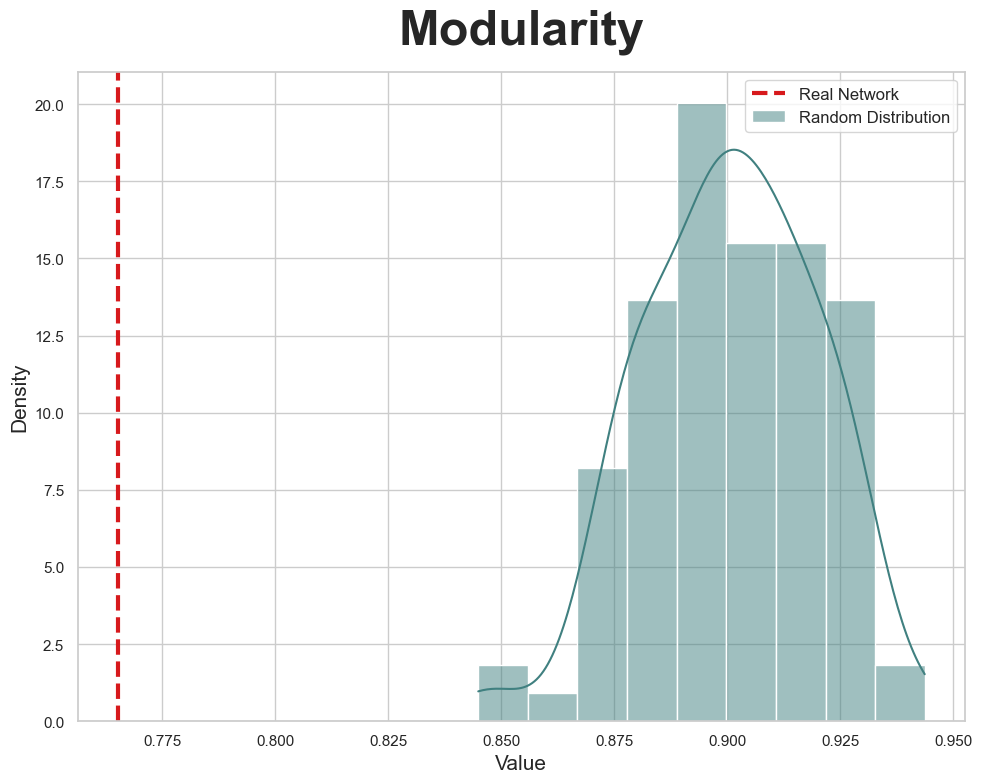

✅ Grafico con campana salvato: clustering_result_uk.png


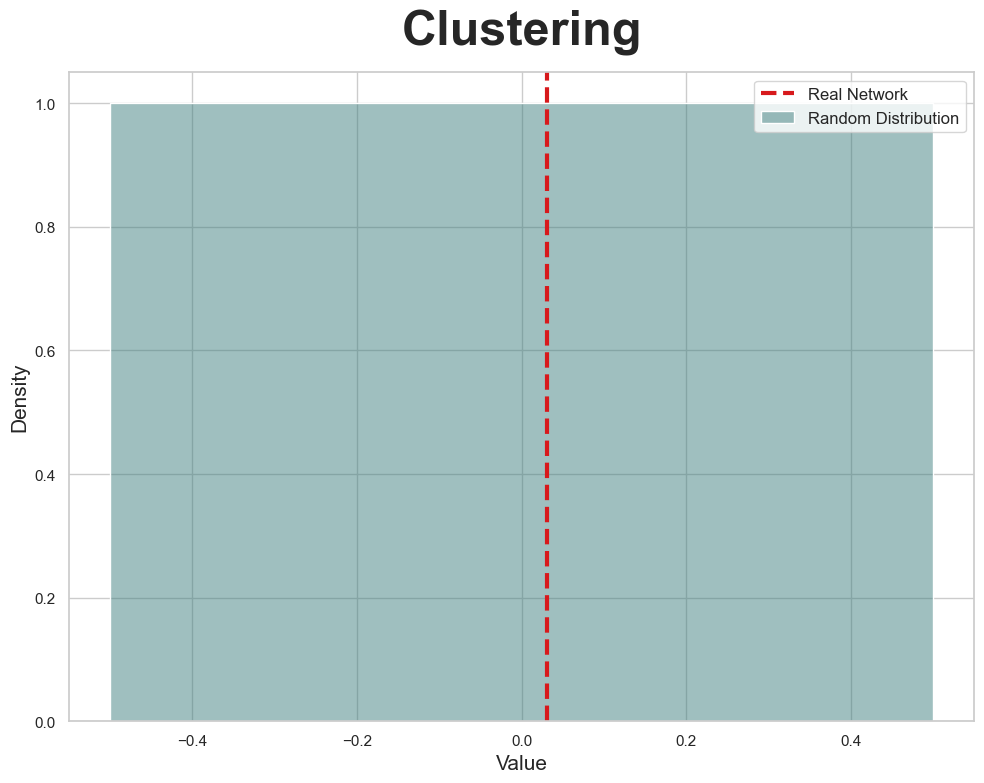

✅ Grafico con campana salvato: betweenness_result_uk.png


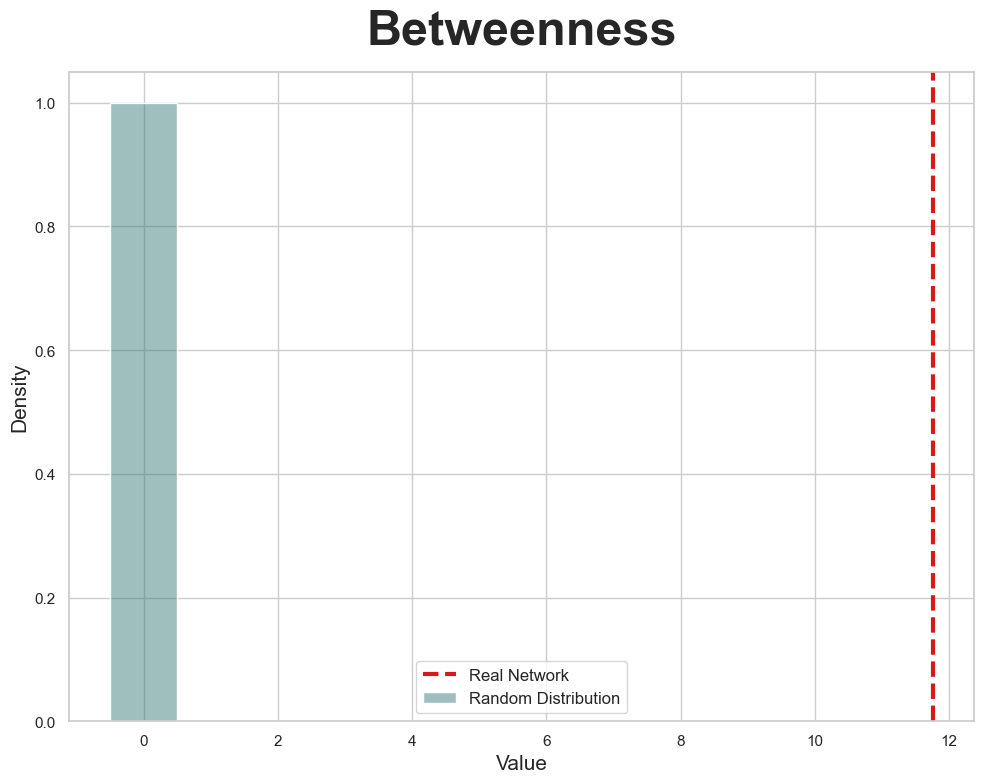

In [220]:
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np

def plot_distribution(random_values, real_value, title):
    # Setup estetico
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 8))
    
    # 1. DISEGNO ISTOGRAMMA + CAMPANA (KDE)
    # stat="density" serve per avere la curva sulla stessa scala dell'istogramma
    sns.histplot(random_values, kde=True, color="#408080", 
                 stat="density", label="Random Distribution", alpha=0.5)
    
    # 2. LINEA REALE
    plt.axvline(real_value, linestyle="--", linewidth=3, color="#D7191C",
                label=f"Real Network")
    
    # 3. TITOLO E ETICHETTE
    plt.title(title, fontsize=35, fontweight='bold', pad=20)
    plt.xlabel("Value", fontsize=15)
    plt.ylabel("Density", fontsize=15)
    plt.legend(fontsize=12)
    
    # 4. OTTIMIZZAZIONE SPAZI E SALVATAGGIO
    plt.tight_layout()
    clean_name = title.lower().replace(" ", "_")
    filename = f"{clean_name}_result_uk.png"
    plt.savefig(filename, dpi=300)
    
    print(f"✅ Grafico con campana salvato: {filename}")
    plt.show()

# Esempio di chiamata
plot_distribution(random_modularity, orig_modularity, "Modularity")
plot_distribution(random_clustering, orig_clustering, "Clustering")
plot_distribution(random_betweenness, orig_betweenness, "Betweenness")

✅ Grafico risolto e salvato: clustering_result_uk.png


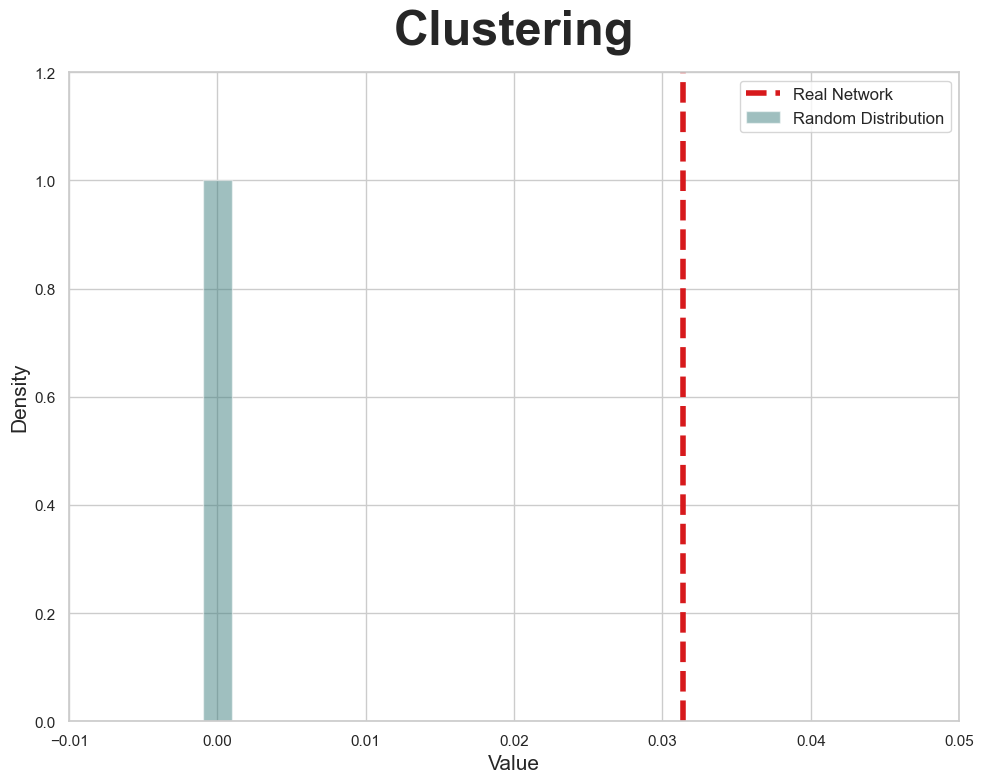

In [221]:
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import numpy as np

def plot_distribution(random_values, real_value, title):
    # 1. Pulizia e calcolo varianza
    data = np.array([x for x in random_values if not np.isnan(x)])
    std_val = np.std(data)
    mean_val = np.mean(data)

    # Setup estetico (IL TUO ORIGINALE)
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 8))
    
    # --- LOGICA DI EMERGENZA PER IL "BLOCCO DI COLORE" ---
    if std_val < 1e-12:
        # Se i dati sono tutti uguali (es. tutti zero), NON USIAMO Seaborn per i dati random.
        # Disegniamo una barra manuale sottile sullo zero.
        plt.bar(mean_val, 1, width=0.002, color="#408080", alpha=0.5, label="Random Distribution")
        
        # FORZIAMO GLI ASSI: Questo impedisce al grafico di "esplodere"
        # Impostiamo una vista che parta da -0.01 fino a poco oltre il valore reale
        xmin = -0.01
        xmax = max(real_value * 1.5, 0.05)
        plt.xlim(xmin, xmax)
        plt.ylim(0, 1.2) # Altezza fissa visto che la densità non è calcolabile
    else:
        # Se c'è varianza, usiamo il tuo histplot ma con i limiti bloccati
        sns.histplot(data, kde=True, color="#408080", stat="density", 
                     label="Random Distribution", alpha=0.5, kde_kws={'cut': 0})
        
        margin = abs(real_value - mean_val) * 0.2
        plt.xlim(min(data.min(), real_value) - margin, max(data.max(), real_value) + margin)

    # 2. LINEA REALE (IL TUO ORIGINALE)
    plt.axvline(real_value, linestyle="--", linewidth=4, color="#D7191C",
                label=f"Real Network")
    
    # 3. TITOLO E ETICHETTE (IL TUO ORIGINALE)
    plt.title(title, fontsize=35, fontweight='bold', pad=20)
    plt.xlabel("Value", fontsize=15)
    plt.ylabel("Density", fontsize=15)
    plt.legend(fontsize=12, loc='upper right')
    
    # 4. SALVATAGGIO
    plt.tight_layout()
    clean_name = title.lower().replace(" ", "_")
    filename = f"{clean_name}_result_uk.png"
    plt.savefig(filename, dpi=300)
    
    print(f"✅ Grafico risolto e salvato: {filename}")
    plt.show()

# Esempio di chiamata
plot_distribution(random_clustering, orig_clustering, "Clustering")